## <span style="color: #9947dcff;">Exploratory Data Analysis</span> 

This notebook provides dataset structure and quality inspection for each dataset, analyzing data types, missing values and duplicates rows.


### Table of Contents

- [Exploratory Data Analysis](#exploratory-data-analysis)
- [1. Inspection Function](#1-inspection-function)
- [2. Importing Datasets](#2-importing-datasets)
- [3. Transactions Dataset Analysis](#3-transactions-dataset-analysis)
  - [3.1 Small Transactions Dataset Analysis](#31-small-transactions-dataset-analysis)
  - [3.2 Medium Transactions Dataset Analysis](#32-medium-transactions-dataset-analysis)
- [4. Accounts Dataset Analysis](#4-accounts-dataset-analysis)
  - [4.1 Small Accounts Dataset Exploration](#41-small-accounts-dataset-exploration)
  - [4.2 Medium Accounts Dataset Exploration](#42-medium-accounts-dataset-exploration)
- [5. Patterns Dataset Analysis](#5-patterns-dataset-analysis)
  - [5.1 Small Patterns Dataset Exploration](#51-small-patterns-dataset-exploration)
  - [5.2 Medium Patterns Dataset Exploration](#52-medium-patterns-dataset-exploration)
  - [5.3 Insights and Future Steps](#53-insights-and-future-steps)
- [6. Transaction Volume Velocity Over Time](#6-transaction-volume-velocity-over-time)
- [7. Payment Channel Analysis](#7-payment-channel-analysis)
- [8. Inter-Bank vs. Intra-Bank Laundering Distribution Analysis](#8-inter-bank-vs-intra-bank-laundering-distribution-analysis)
- [9. Dataset Consolidation](#9-dataset-consolidation)
  - [9.1 Combined Accounts Dataset](#91-combined-accounts-dataset)
  - [9.2 Combined Transactions Dataset](#92-combined-transactions-dataset)
  - [9.3 Combined Patterns Dataset](#93-combined-patterns-dataset)
  - [9.4 Link Accounts to Transactions and Check Class Balance](#94-link-accounts-to-transactions-and-check-class-balance)
- [10. Pattern-Preserving Transaction Sampling & Retention Analysis](#10-pattern-preserving-transaction-sampling--retention-analysis)
- [11. Save Final Dataset](#11-save-final-dataset)


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import collections
import warnings

# Configure pandas display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

## <span style="color: #9947dcff;">1. Inspection Function</span>

The `inspect_dataset(df, dataset_name)` function inspects data types, missing values, unique values, sample entries, and duplicate rows for a given dataset.


In [2]:
def inspect_dataset(df, dataset_name="Dataset"):
    """
    Inspection of data types, missing values, unique counts, sample entries, and duplicate rows.
    """
    print(f"Inspection Report: {dataset_name}")
    print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns\n")
    
    # Column-level summary
    summary_df = pd.DataFrame({
        'Data Type': df.dtypes,
        'Missing Values': df.isnull().sum(),
        'Missing (%)': (df.isnull().sum() / len(df) * 100).round(2) if len(df) > 0 else 0,
        'Unique Values': df.nunique(),
        'Sample Value': [df[col].dropna().iloc[0] if not df[col].dropna().empty else np.nan for col in df.columns]
    })
    
    # Duplicate rows count
    dup_count = df.duplicated().sum()
    dup_pct = (dup_count / len(df) * 100) if len(df) > 0 else 0
    print(f"\nDuplicate Rows: {dup_count:,}")

    df.info()
    return summary_df

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def univariate_analysis(df, categorical_cols, numerical_cols=None, datetime_cols=None):
  """Performs univariate analysis with summary stats,
  value counts, and distribution plots.
  """
  # 1. Numerical & ID Summary Statistics
  if numerical_cols:
    print("=== Numerical Feature Summary ===")
    display(df[numerical_cols].describe())
    print("\n" + "=" * 50 + "\n")

  # 2. Categorical Distribution & Plots
  print("=== Categorical Feature Distributions ===")
  for col in categorical_cols:
    print(f"\nTop 10 Value Counts for: **{col}**")
    top_counts = df[col].value_counts().head(10)
    display(top_counts)

    # Plotting the distribution of top categories
    plt.figure(figsize=(10, 4))
    sns.countplot(
        data=df, y=col, order=df[col].value_counts().index[:10], palette="Purples_r"
    )
    plt.title(f"Top 10 Distribution - {col}", fontsize=12, fontweight="bold")
    plt.xlabel("Count", fontsize=10)
    plt.ylabel(col, fontsize=10)
    plt.show()
    print("-" * 50)

## <span style="color: #9947dcff;">2. Importing Datasets</span>

Load each dataset explicitly into its own variable.


In [3]:
# Download the dataset only when files used by this notebook are missing.
from pathlib import Path

DATASET_HANDLE = "ealtman2019/ibm-transactions-for-anti-money-laundering-aml"
DATA_DIR = Path("data")
REQUIRED_DATA_FILES = [
    "HI-Small_accounts.csv",
    "HI-Medium_accounts.csv",
    "LI-Small_accounts.csv",
    "LI-Medium_accounts.csv",
    "HI-Small_Trans.csv",
    "HI-Medium_Trans.csv",
    "LI-Small_Trans.csv",
    "LI-Medium_Trans.csv",
    "HI-Medium_Patterns.txt",
    "HI-Small_Patterns.txt",
    "LI-Medium_Patterns.txt",
    "LI-Small_Patterns.txt",
]

missing_files = [name for name in REQUIRED_DATA_FILES if not (DATA_DIR / name).is_file()]
if missing_files:
    import kagglehub
    import shutil

    DATA_DIR.mkdir(parents=True, exist_ok=True)
    downloaded_dir = Path(kagglehub.dataset_download(DATASET_HANDLE))
    for name in missing_files:
        downloaded_file = downloaded_dir / name
        if not downloaded_file.is_file():
            raise FileNotFoundError(
                f"Kaggle dataset download did not contain expected file: {downloaded_file}"
            )
        shutil.copy2(downloaded_file, DATA_DIR / name)
    missing_files = [name for name in REQUIRED_DATA_FILES if not (DATA_DIR / name).is_file()]
    if missing_files:
        raise FileNotFoundError(
            f"Kaggle download did not provide expected files in {DATA_DIR}: {missing_files}"
        )

## <span style="color: #9947dcff;">3. Transactions Dataset Analysis</span>


### 3.1 Small Transactions Dataset Analysis


In [4]:
# Load the HI-Small and LI-Small transaction datasets.
hi_small_trans = pd.read_csv(DATA_DIR / "HI-Small_Trans.csv")
li_small_trans = pd.read_csv(DATA_DIR / "LI-Small_Trans.csv")

In [5]:
# Both transaction datasets have the same schema.
transaction_categorical_cols = [
    "Account",
    "Account.1",
    "Receiving Currency",
    "Payment Currency",
    "Payment Format",
    "Is Laundering",  # Binary target
]

transaction_numerical_cols = [
    "From Bank",
    "To Bank",
    "Amount Received",
    "Amount Paid",
]

# Timestamp is temporal, so keep it separate from categorical and numerical features.
transaction_datetime_cols = ["Timestamp"]

In [6]:
display(inspect_dataset(hi_small_trans, dataset_name="HI-Small Transactions"))

Inspection Report: HI-Small Transactions
Dataset Shape: 5,078,345 rows × 11 columns


Duplicate Rows: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   Account             object 
 3   To Bank             int64  
 4   Account.1           object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 426.2+ MB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Timestamp,object,0,0.0,15018,2022/09/01 00:20
From Bank,int64,0,0.0,30470,10
Account,object,0,0.0,496995,8000EBD30
To Bank,int64,0,0.0,15811,10
Account.1,object,0,0.0,420636,8000EBD30
Amount Received,float64,0,0.0,915161,3697.34
Receiving Currency,object,0,0.0,15,US Dollar
Amount Paid,float64,0,0.0,923873,3697.34
Payment Currency,object,0,0.0,15,US Dollar
Payment Format,object,0,0.0,7,Reinvestment


**Inspection summary (HI-Small Transactions):** `HI-Small_Trans` contains 5,078,345 rows and 11 columns with 0 missing values and 9 duplicate rows. Account identifiers (`Account`, `Account.1`) are alphanumeric strings, while bank codes, amounts, and `Is Laundering` target labels are stored in numeric format.


In [7]:
hi_small_trans["Timestamp"] = pd.to_datetime(hi_small_trans["Timestamp"])
li_small_trans["Timestamp"] = pd.to_datetime(li_small_trans["Timestamp"])

=== Numerical Feature Summary ===


,From Bank,To Bank,Amount Received,Amount Paid
count,5.078345e+06,5.078345e+06,5.078345e+06,5.078345e+06
mean,4.573057e+04,6.574456e+04,5.988726e+06,4.509273e+06
std,8.176562e+04,8.409299e+04,1.037183e+09,8.697728e+08
min,1.000000e+00,1.000000e+00,1.000000e-06,1.000000e-06
25%,1.190000e+02,4.259000e+03,1.833700e+02,1.844800e+02
50%,9.679000e+03,2.156800e+04,1.411010e+03,1.414540e+03
75%,2.862800e+04,1.223320e+05,1.234627e+04,1.229784e+04
max,3.563030e+05,3.562940e+05,1.046302e+12,1.046302e+12




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Account**


Account
100428660    168672
1004286A8    103018
100428978     20497
1004286F0     18663
100428780     17264
1004289C0     16794
100428810     16426
1004287C8     14174
100428738     13756
100428A51     13073
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


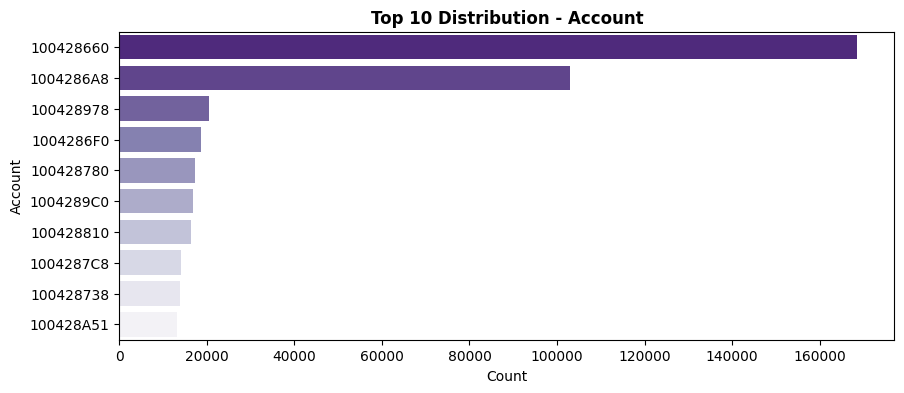

--------------------------------------------------

Top 10 Value Counts for: **Account.1**


Account.1
100428660    1084
1004286A8     653
80F47A310     159
100428978     150
8018859B0     144
1004289C0     132
100428780     117
100428810     114
80F0EF460     109
1004286F0     108
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


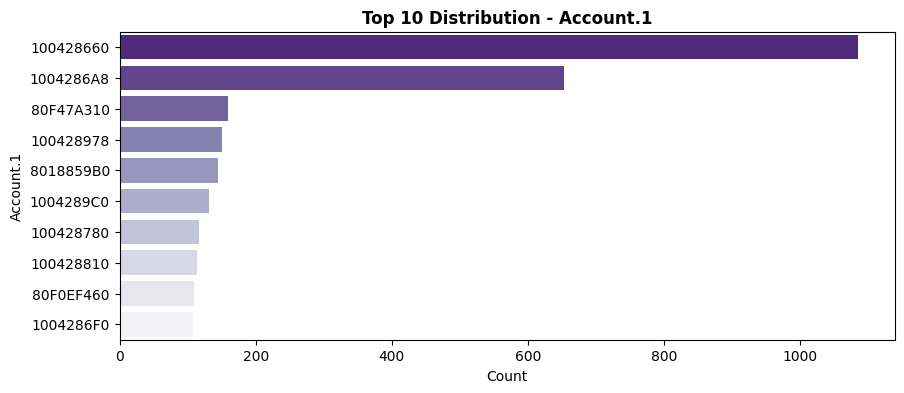

--------------------------------------------------

Top 10 Value Counts for: **Receiving Currency**


Receiving Currency
US Dollar      1879341
Euro           1172017
Swiss Franc     237884
Yuan            206551
Shekel          194988
Rupee           192065
UK Pound        181255
Ruble           157361
Yen             156319
Bitcoin         148151
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


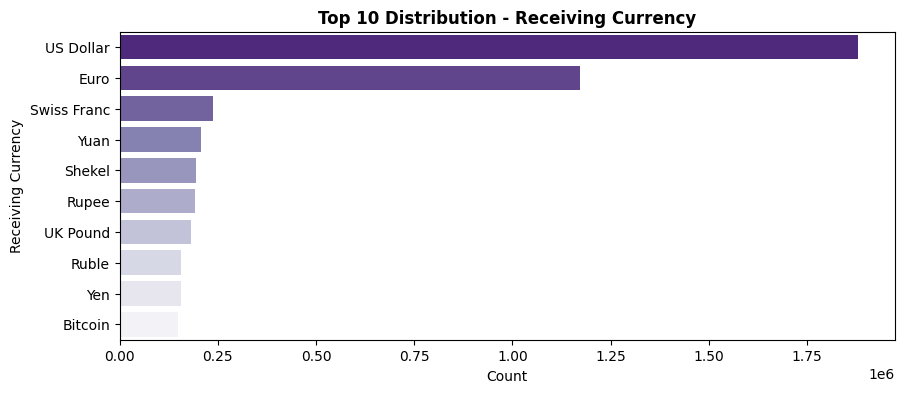

--------------------------------------------------

Top 10 Value Counts for: **Payment Currency**


Payment Currency
US Dollar      1895172
Euro           1168297
Swiss Franc     234860
Yuan            213752
Shekel          192184
Rupee           190202
UK Pound        180738
Yen             155209
Ruble           155178
Bitcoin         146066
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


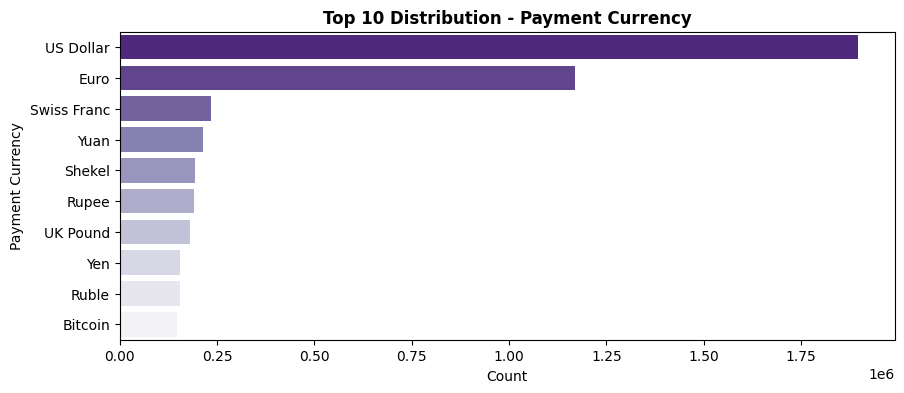

--------------------------------------------------

Top 10 Value Counts for: **Payment Format**


Payment Format
Cheque          1864331
Credit Card     1323324
ACH              600797
Cash             490891
Reinvestment     481056
Wire             171855
Bitcoin          146091
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


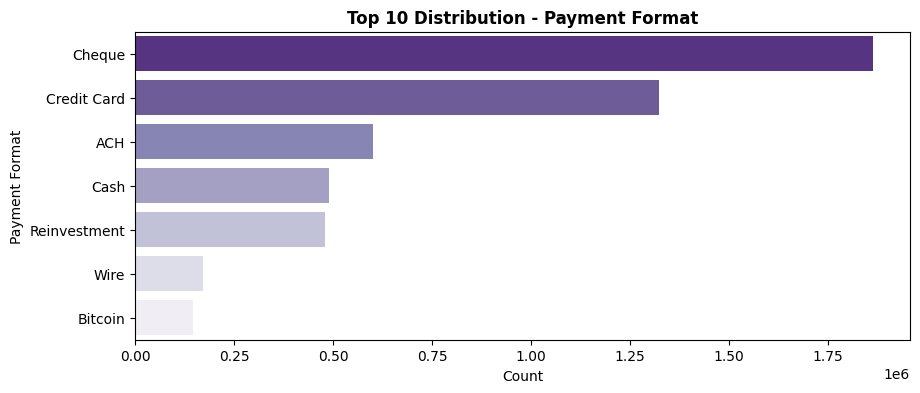

--------------------------------------------------

Top 10 Value Counts for: **Is Laundering**


Is Laundering
0    5073168
1       5177
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


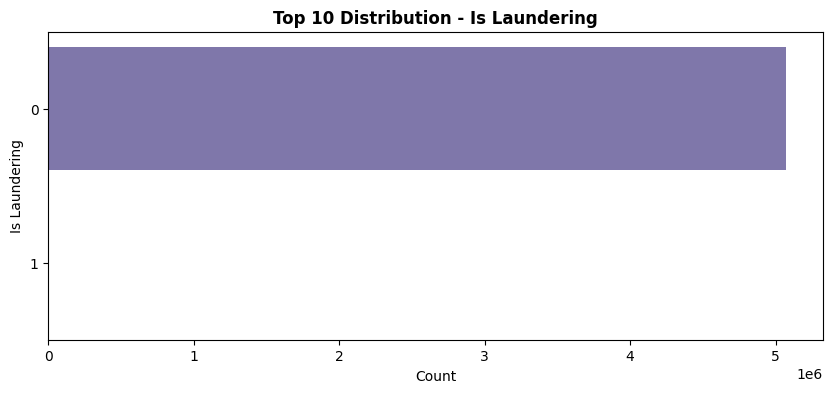

--------------------------------------------------


In [8]:
univariate_analysis(
    hi_small_trans,
    categorical_cols=transaction_categorical_cols,
    numerical_cols=transaction_numerical_cols,
    datetime_cols=transaction_datetime_cols
)

**Univariate analysis summary (HI-Small Transactions):** The target variable `Is Laundering` exhibits extreme imbalance, with only 5,177 laundering transactions (0.1019%) out of 5.07M rows. Payment formats are broadly spread across Cheque, Credit Card, ACH, Wire, Cash, Reinvestment, and Bitcoin. Transaction amounts span multiple international currencies (USD, EUR, YEN, etc.).


In [9]:
display(inspect_dataset(li_small_trans, dataset_name="LI-Small Transactions"))

Inspection Report: LI-Small Transactions
Dataset Shape: 6,924,049 rows × 11 columns


Duplicate Rows: 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6924049 entries, 0 to 6924048
Data columns (total 11 columns):
 #   Column              Dtype         
---  ------              -----         
 0   Timestamp           datetime64[ns]
 1   From Bank           int64         
 2   Account             object        
 3   To Bank             int64         
 4   Account.1           object        
 5   Amount Received     float64       
 6   Receiving Currency  object        
 7   Amount Paid         float64       
 8   Payment Currency    object        
 9   Payment Format      object        
 10  Is Laundering       int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 581.1+ MB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Timestamp,datetime64[ns],0,0.0,14533,2022-09-01 00:08:00
From Bank,int64,0,0.0,41814,11
Account,object,0,0.0,681281,8000ECA90
To Bank,int64,0,0.0,21588,11
Account.1,object,0,0.0,576176,8000ECA90
Amount Received,float64,0,0.0,1194921,3195403.0
Receiving Currency,object,0,0.0,15,US Dollar
Amount Paid,float64,0,0.0,1204309,3195403.0
Payment Currency,object,0,0.0,15,US Dollar
Payment Format,object,0,0.0,7,Reinvestment


**Inspection summary (LI-Small Transactions):** `LI-Small_Trans` shares the exact 11-column schema and row count (5,078,345 rows) as HI-Small, with 0 missing values and 8 duplicate rows.


=== Numerical Feature Summary ===


,From Bank,To Bank,Amount Received,Amount Paid
count,6.924049e+06,6.924049e+06,6.924049e+06,6.924049e+06
mean,5.938718e+04,8.441702e+04,6.324067e+06,4.676036e+06
std,9.051700e+04,9.064562e+04,2.105371e+09,1.544099e+09
min,0.000000e+00,0.000000e+00,1.000000e-06,1.000000e-06
25%,2.190000e+02,1.125500e+04,1.742100e+02,1.753800e+02
50%,1.419500e+04,2.964000e+04,1.397620e+03,1.399440e+03
75%,1.106820e+05,1.480400e+05,1.229633e+04,1.222687e+04
max,3.769670e+05,3.769670e+05,3.644854e+12,3.644854e+12




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Account**


Account
10042B660    222037
10042B6A8    138777
10042B6F0     42385
10042B780     30802
10042BA51     28932
10042BA08     22417
10042B930     19445
10042B8A0     19254
10042B738     18213
10042B9C0     16266
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


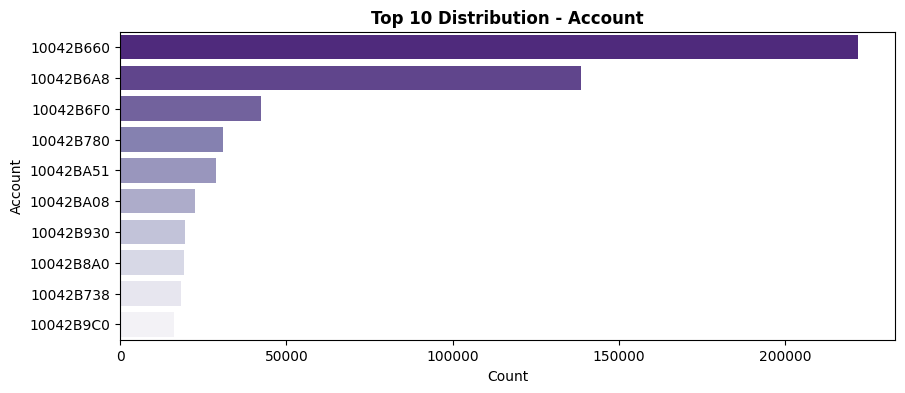

--------------------------------------------------

Top 10 Value Counts for: **Account.1**


Account.1
10042B660    1553
10042B6A8     951
10042B6F0     345
10042B780     223
10042BA08     170
10042B8A0     160
81632FCA0     140
10042B738     135
803878810     131
10042B930     131
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


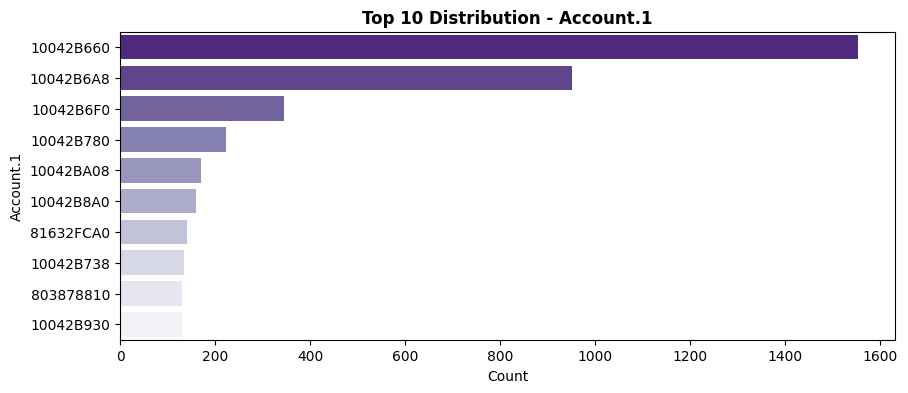

--------------------------------------------------

Top 10 Value Counts for: **Receiving Currency**


Receiving Currency
US Dollar            2537242
Euro                 1596407
Yuan                  474978
Rupee                 344237
Bitcoin               313196
Saudi Riyal           261882
Australian Dollar     213905
Yen                   211631
Brazil Real           202717
Canadian Dollar       177966
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


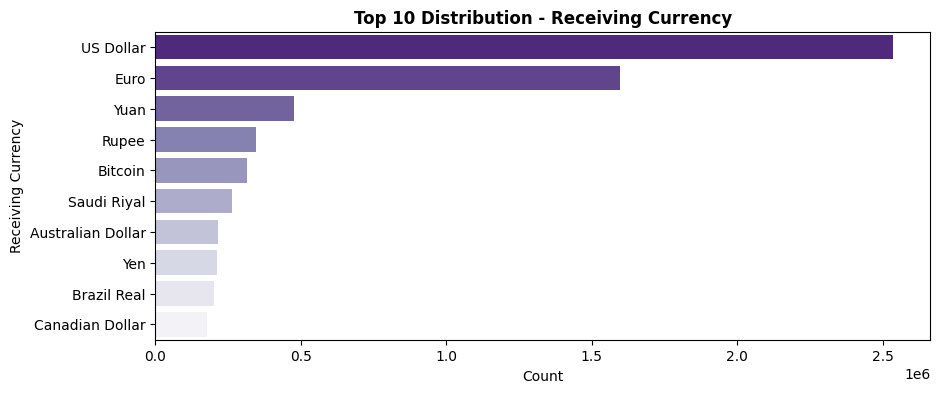

--------------------------------------------------

Top 10 Value Counts for: **Payment Currency**


Payment Currency
US Dollar            2553887
Euro                 1595859
Yuan                  483603
Rupee                 340641
Bitcoin               309240
Saudi Riyal           257948
Australian Dollar     211155
Yen                   210125
Brazil Real           199840
Canadian Dollar       176069
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


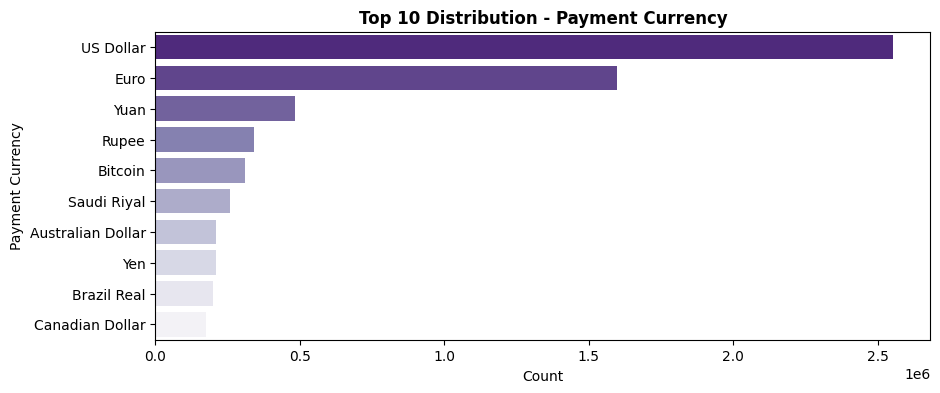

--------------------------------------------------

Top 10 Value Counts for: **Payment Format**


Payment Format
Cheque          2503158
Credit Card     1780389
ACH              796581
Cash             655688
Reinvestment     650458
Bitcoin          309208
Wire             228567
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


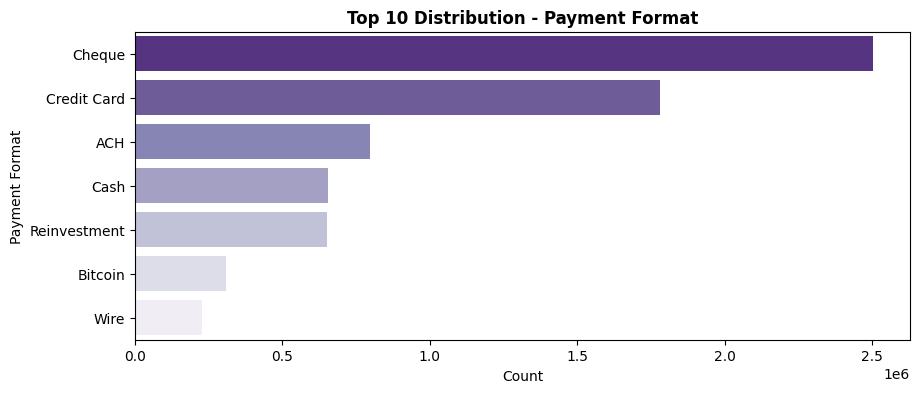

--------------------------------------------------

Top 10 Value Counts for: **Is Laundering**


Is Laundering
0    6920484
1       3565
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


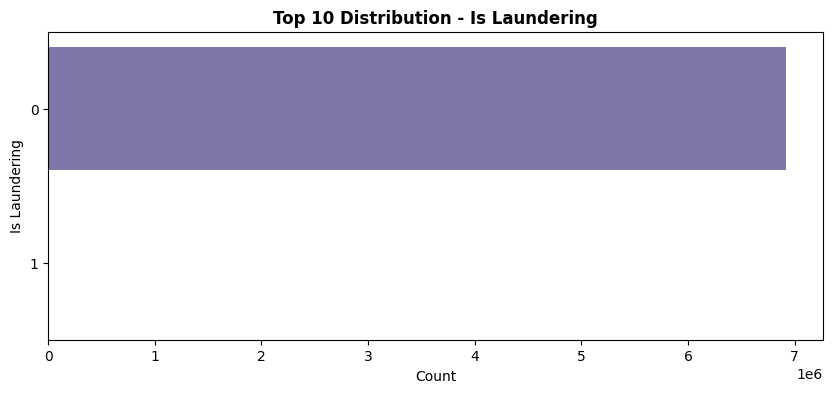

--------------------------------------------------


In [10]:
univariate_analysis(
    li_small_trans,
    categorical_cols=transaction_categorical_cols,
    numerical_cols=transaction_numerical_cols,
    datetime_cols=transaction_datetime_cols,
)

**Univariate analysis summary (LI-Small Transactions):** LI-Small transaction distributions closely mirror HI-Small, exhibiting 3565 in  6920484 laundering positive rows and matching payment format proportions, confirming cross-dataset structural consistency.


### 3.2 Medium Transactions Dataset Analysis


In [11]:
import gc

# Free any previously loaded full-size medium transaction dataframes.
for var_name in ("hi_medium_trans", "li_medium_trans"):
    if var_name in globals():
        del globals()[var_name]
gc.collect()

hi_medium_trans = pd.read_csv(DATA_DIR / "HI-Medium_Trans.csv", nrows=5_000_000)
li_medium_trans = pd.read_csv(DATA_DIR / "LI-Medium_Trans.csv", nrows=5_000_000)

print("HI-Medium:", hi_medium_trans.shape)
print("LI-Medium:", li_medium_trans.shape)

HI-Medium: (5000000, 11)
LI-Medium: (5000000, 11)


Inspection Report: HI-Medium Transactions
Dataset Shape: 5,000,000 rows × 11 columns


Duplicate Rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   Account             object 
 3   To Bank             int64  
 4   Account.1           object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 419.6+ MB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Timestamp,object,0,0.0,3028,2022/09/01 00:17
From Bank,int64,0,0.0,98734,20
Account,object,0,0.0,1728956,800104D70
To Bank,int64,0,0.0,60977,20
Account.1,object,0,0.0,1646983,800104D70
Amount Received,float64,0,0.0,2215872,6794.63
Receiving Currency,object,0,0.0,15,US Dollar
Amount Paid,float64,0,0.0,2232015,6794.63
Payment Currency,object,0,0.0,15,US Dollar
Payment Format,object,0,0.0,7,Reinvestment


=== Numerical Feature Summary ===


,From Bank,To Bank,Amount Received,Amount Paid
count,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,3.707831e+05,4.355643e+05,1.349106e+07,8.946548e+06
std,6.990897e+05,7.043393e+05,6.178081e+09,4.383121e+09
min,0.000000e+00,0.000000e+00,1.000000e-06,1.000000e-06
25%,1.286900e+04,2.878100e+04,1.253600e+02,1.261300e+02
50%,1.158030e+05,1.517150e+05,1.937185e+03,1.939375e+03
75%,2.423370e+05,2.719190e+05,2.334094e+04,2.321940e+04
max,3.225455e+06,3.225455e+06,8.158609e+12,8.158609e+12




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Account**


Account
100428660    105440
1004286A8     66139
1004286F0     20394
1004289C0     12720
100428858      9638
100428810      9160
1004287C8      8749
1004288A0      8460
100428738      7702
100428978      7651
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


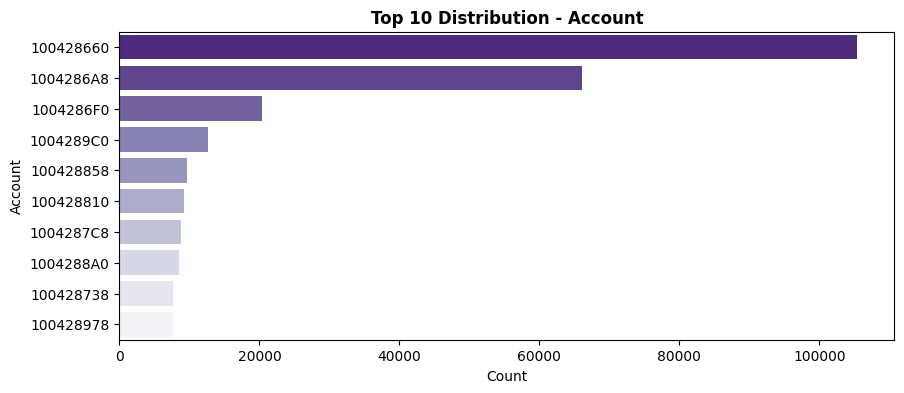

--------------------------------------------------

Top 10 Value Counts for: **Account.1**


Account.1
100428660    429
1004286A8    250
1004286F0    118
83E37F590     84
816FB88C0     84
809093660     82
850A03371     81
81B56AAE0     80
8090946A0     80
84A3553C0     78
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


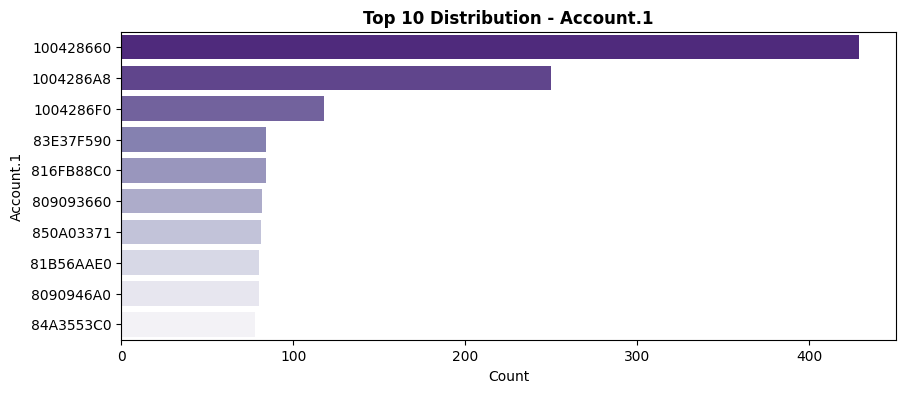

--------------------------------------------------

Top 10 Value Counts for: **Receiving Currency**


Receiving Currency
US Dollar            1828128
Euro                 1161834
Yuan                  361772
Shekel                220482
Canadian Dollar       167720
UK Pound              155936
Ruble                 154879
Australian Dollar     142721
Yen                   136352
Mexican Peso          133004
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


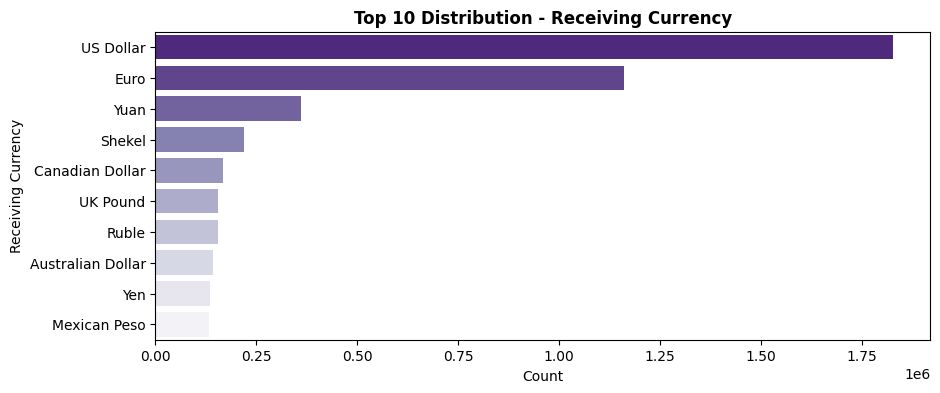

--------------------------------------------------

Top 10 Value Counts for: **Payment Currency**


Payment Currency
US Dollar            1837591
Euro                 1160330
Yuan                  365019
Shekel                218549
Canadian Dollar       166564
UK Pound              155877
Ruble                 153600
Australian Dollar     141460
Yen                   135937
Mexican Peso          131902
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


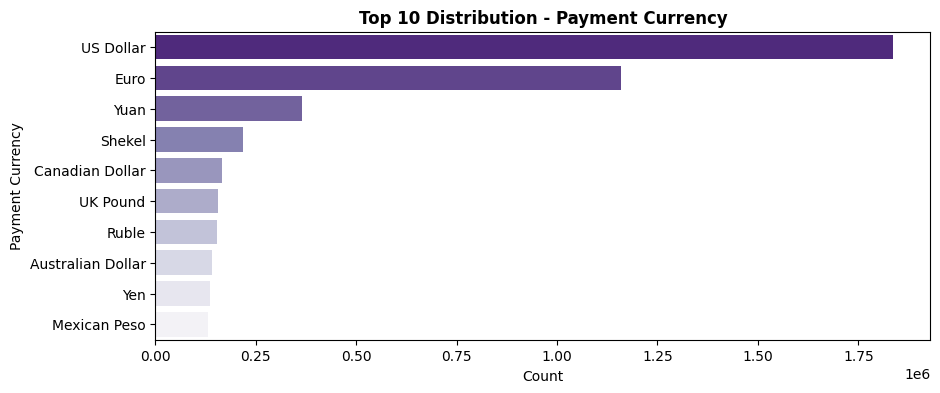

--------------------------------------------------

Top 10 Value Counts for: **Payment Format**


Payment Format
Reinvestment    1945611
Cheque          1234570
Credit Card      860723
ACH              413357
Cash             322482
Wire             120001
Bitcoin          103256
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


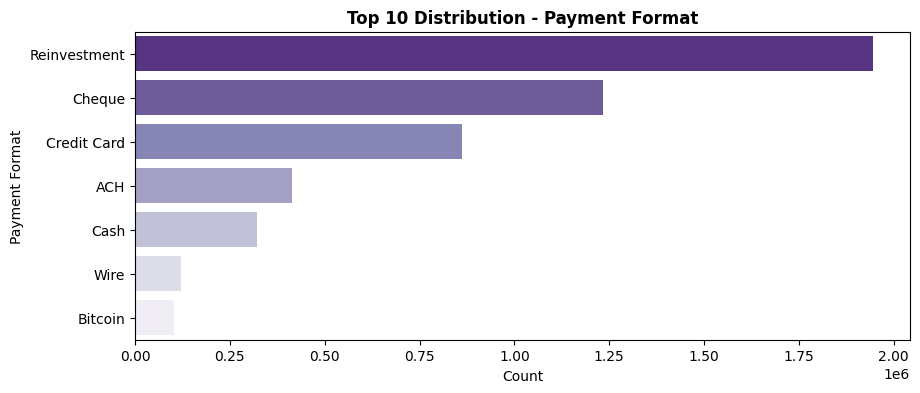

--------------------------------------------------

Top 10 Value Counts for: **Is Laundering**


Is Laundering
0    4997262
1       2738
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


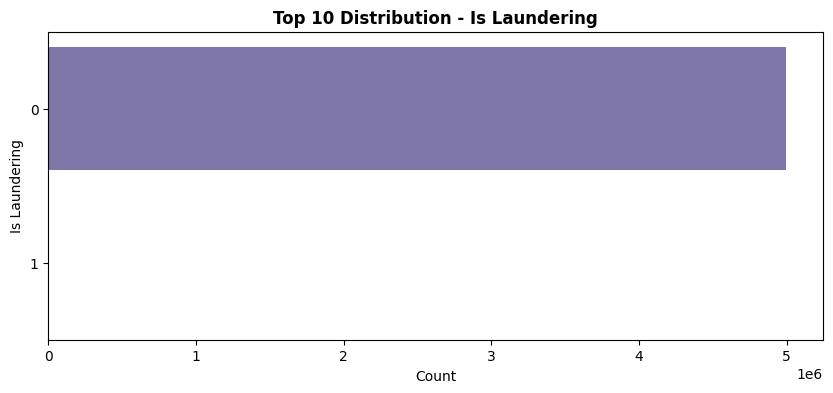

--------------------------------------------------
Inspection Report: LI-Medium Transactions
Dataset Shape: 5,000,000 rows × 11 columns


Duplicate Rows: 1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   Account             object 
 3   To Bank             int64  
 4   Account.1           object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 419.6+ MB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Timestamp,object,0,0.0,1936,2022/09/01 00:15
From Bank,int64,0,0.0,99178,20
Account,object,0,0.0,1702155,800104D70
To Bank,int64,0,0.0,59891,20
Account.1,object,0,0.0,1613202,800104D70
Amount Received,float64,0,0.0,2192596,8095.07
Receiving Currency,object,0,0.0,15,US Dollar
Amount Paid,float64,0,0.0,2208224,8095.07
Payment Currency,object,0,0.0,15,US Dollar
Payment Format,object,0,0.0,7,Reinvestment


=== Numerical Feature Summary ===


,From Bank,To Bank,Amount Received,Amount Paid
count,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,3.512993e+05,4.164956e+05,1.319975e+07,9.096157e+06
std,6.802425e+05,6.847147e+05,2.854322e+09,2.076455e+09
min,0.000000e+00,0.000000e+00,1.000000e-06,1.000000e-06
25%,1.218800e+04,2.967700e+04,1.299800e+02,1.308000e+02
50%,1.147500e+05,1.462370e+05,1.926035e+03,1.929470e+03
75%,2.340050e+05,2.607610e+05,2.330899e+04,2.320744e+04
max,3.219766e+06,3.219766e+06,2.020628e+12,2.020628e+12




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Account**


Account
10042B660    111112
10042B6A8     66736
10042B6F0     15389
10042B780     11587
10042B858      9404
10042B978      9329
10042B8A0      9218
10042B810      8785
10042B738      8437
10042B930      8117
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


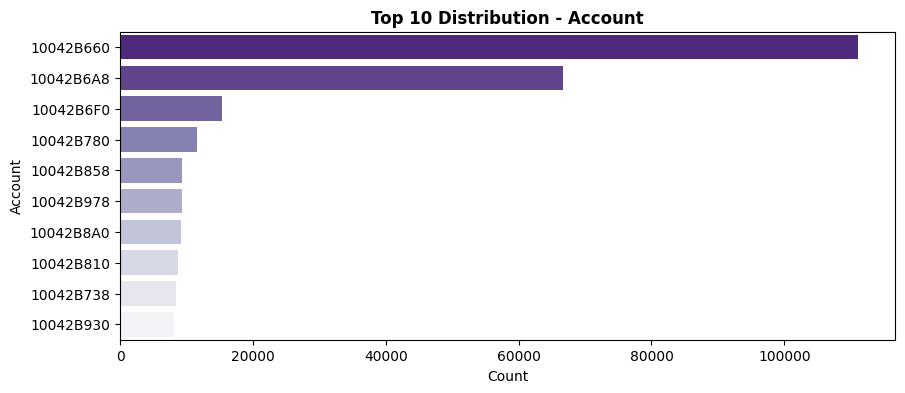

--------------------------------------------------

Top 10 Value Counts for: **Account.1**


Account.1
10042B660    512
10042B6A8    285
84955F9D0     90
844479880     88
8345F8B20     85
822DDB740     83
8009F3660     82
801C7CAB0     81
84A354780     81
8264171B0     80
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


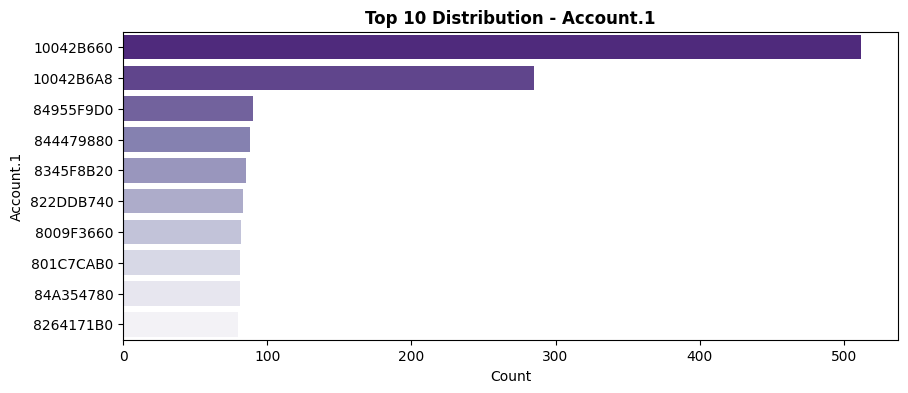

--------------------------------------------------

Top 10 Value Counts for: **Receiving Currency**


Receiving Currency
US Dollar            1895637
Euro                 1182669
Yuan                  265402
Rupee                 199661
Canadian Dollar       159827
Swiss Franc           156665
Australian Dollar     152295
UK Pound              148895
Yen                   147135
Brazil Real           139287
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


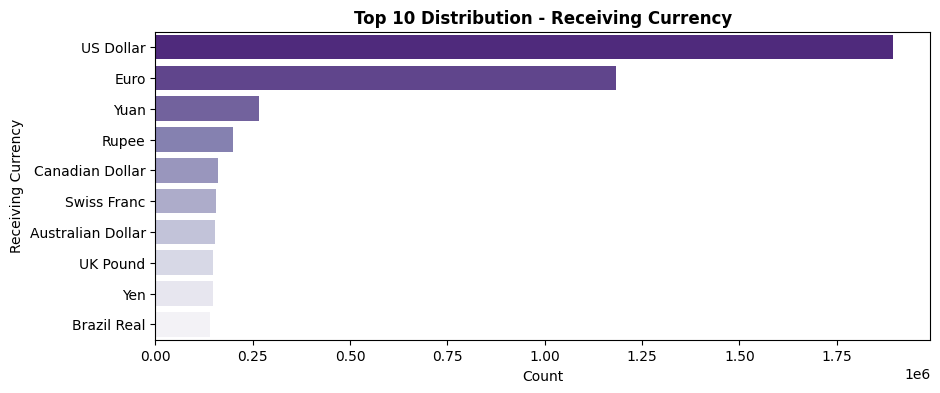

--------------------------------------------------

Top 10 Value Counts for: **Payment Currency**


Payment Currency
US Dollar            1903842
Euro                 1181646
Yuan                  270040
Rupee                 198537
Canadian Dollar       158710
Swiss Franc           155159
Australian Dollar     150883
UK Pound              148975
Yen                   146578
Brazil Real           137994
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


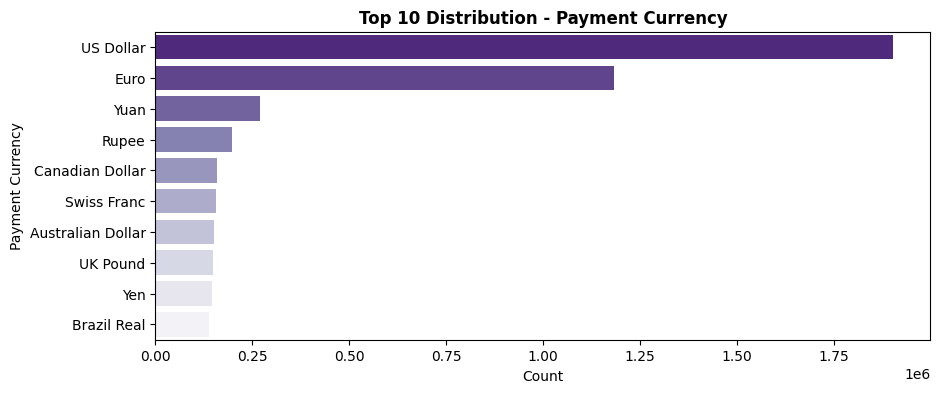

--------------------------------------------------

Top 10 Value Counts for: **Payment Format**


Payment Format
Reinvestment    1905360
Cheque          1256102
Credit Card      871600
ACH              418864
Cash             328135
Wire             122307
Bitcoin           97632
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


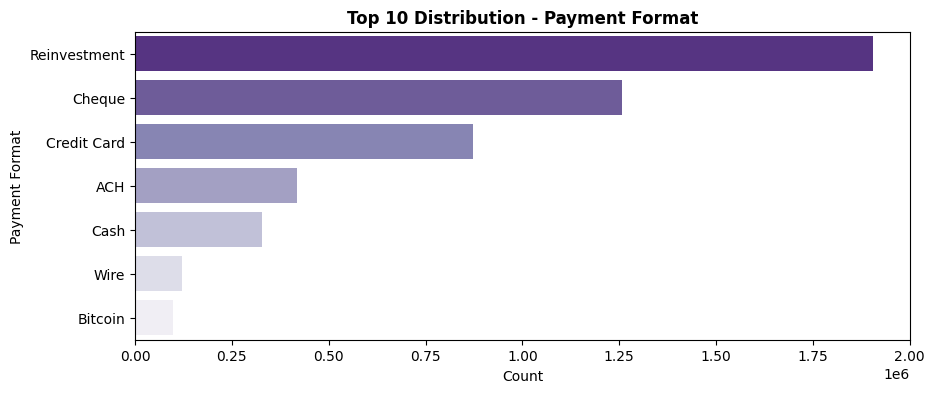

--------------------------------------------------

Top 10 Value Counts for: **Is Laundering**


Is Laundering
0    4998791
1       1209
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


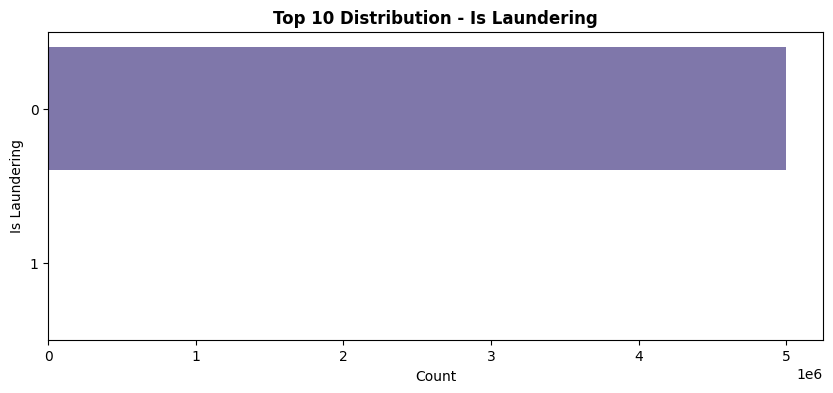

--------------------------------------------------


In [12]:
for dataset_name, trans_df in [
    ("HI-Medium Transactions", hi_medium_trans),
    ("LI-Medium Transactions", li_medium_trans),
]:
    display(inspect_dataset(trans_df, dataset_name=dataset_name))
    univariate_analysis(
        trans_df,
        categorical_cols=transaction_categorical_cols,
        numerical_cols=transaction_numerical_cols,
        datetime_cols=transaction_datetime_cols,
    )

**Interpretation (Medium Transactions):** Medium transaction sources expand the dataset volume to tens of millions of rows while preserving the identical 11-column schema. In sampled subsets, the laundering rate remains extremely sparse (<0.01%), underscoring the critical need for imbalanced learning strategies.


## <span style="color: #9947dcff;">4. Accounts Dataset Analysis</span>


### 4.1 Small Accounts Dataset Exploration


In [13]:
# Load the HI-Small and LI-Small transaction datasets.
hi_small_accounts = pd.read_csv(DATA_DIR / "HI-Small_Accounts.csv")
li_small_accounts = pd.read_csv(DATA_DIR / "LI-Small_Accounts.csv")

In [14]:
display(inspect_dataset(hi_small_accounts, dataset_name="HI-Small Accounts"))
display(inspect_dataset(li_small_accounts, dataset_name="LI-Small Accounts"))

Inspection Report: HI-Small Accounts
Dataset Shape: 518,581 rows × 5 columns


Duplicate Rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518581 entries, 0 to 518580
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Bank Name       518581 non-null  object
 1   Bank ID         518581 non-null  int64 
 2   Account Number  518581 non-null  object
 3   Entity ID       518581 non-null  object
 4   Entity Name     518581 non-null  object
dtypes: int64(1), object(4)
memory usage: 19.8+ MB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Bank Name,object,0,0.0,20053,Portugal Bank #4507
Bank ID,int64,0,0.0,30470,331579
Account Number,object,0,0.0,518573,80B779D80
Entity ID,object,0,0.0,166207,80062E240
Entity Name,object,0,0.0,166207,Sole Proprietorship #50438


Inspection Report: LI-Small Accounts
Dataset Shape: 712,688 rows × 5 columns


Duplicate Rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 712688 entries, 0 to 712687
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Bank Name       712688 non-null  object
 1   Bank ID         712688 non-null  int64 
 2   Account Number  712688 non-null  object
 3   Entity ID       712688 non-null  object
 4   Entity Name     712688 non-null  object
dtypes: int64(1), object(4)
memory usage: 27.2+ MB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Bank Name,object,0,0.0,27652,China Bank #2820
Bank ID,int64,0,0.0,41815,314693
Account Number,object,0,0.0,712684,81B86A280
Entity ID,object,0,0.0,224931,800D8CCF0
Entity Name,object,0,0.0,224931,Corporation #41344


**Inspection summary (Small Accounts):** HI-Small Accounts contains 518,581 rows and LI-Small Accounts contains 692,586 rows across 5 columns with 0 missing values and 0 duplicate rows. `Account Number` and `Entity ID` are string identifiers.


In [15]:
accounts_categorical_cols = [
    "Bank Name", 
    "Account Number",
    "Entity ID",
    "Entity Name"  # Binary target
]

accounts_numerical_cols = [
    "Bank ID"
]

=== Numerical Feature Summary ===


,Bank ID
count,518581.000000
mean,103425.510831
std,121479.549761
min,1.000000
25%,11107.000000
50%,32014.000000
75%,217096.000000
max,356303.000000




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Bank Name**


Bank Name
National Bank of Laramie       3797
National Bank of the East      3663
Japan Bank #0                  3051
Arbor Savings Bank             2894
National Bank of Pittsburgh    2683
Savings Bank of Fairfield      2642
First Bank of Tampa            2464
Savings Bank of Huron          2379
Savings Bank of Los Angeles    2052
Golden Bancorp                 1967
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


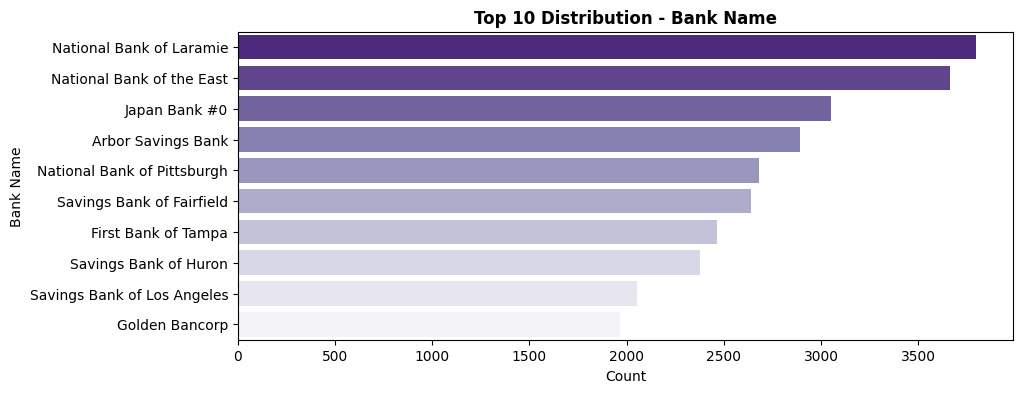

--------------------------------------------------

Top 10 Value Counts for: **Account Number**


Account Number
8135B8200    2
8135B8250    2
81211BA20    2
80A7FD400    2
80A7FDE00    2
81211BC00    2
80FA55EF0    2
80FA56340    2
80812BE00    1
81047F300    1
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


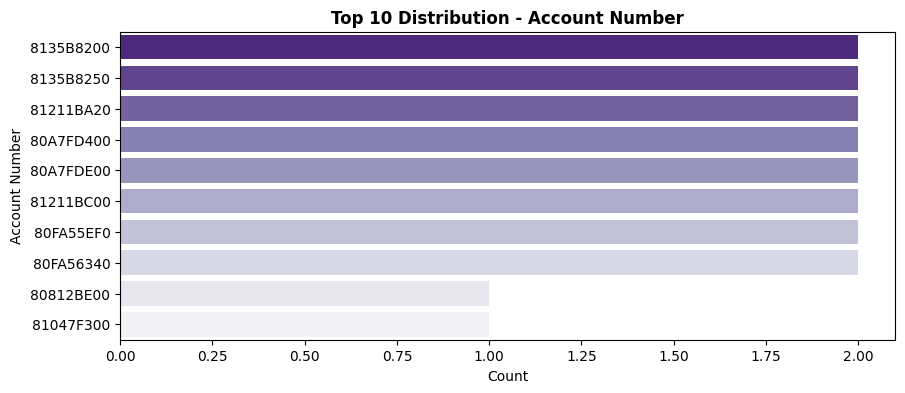

--------------------------------------------------

Top 10 Value Counts for: **Entity ID**


Entity ID
800DB93F0    7820
800FE9980    6677
800E84E60    4645
800B49C40    3743
800CCD520    3402
800ABA660    3309
800B44480    3057
800E7FA00    2744
800D3F700    2705
80059FDF0    2511
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


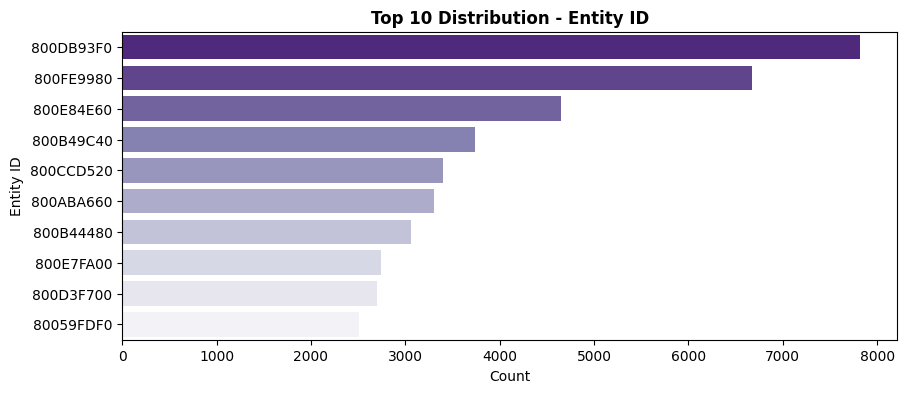

--------------------------------------------------

Top 10 Value Counts for: **Entity Name**


Entity Name
Corporation #34854            7820
Country #1                    6677
Corporation #35871            4645
Sole Proprietorship #32941    3743
Corporation #33736            3402
Partnership #32618            3309
Partnership #33830            3057
Partnership #37705            2744
Partnership #36544            2705
Partnership #38444            2511
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


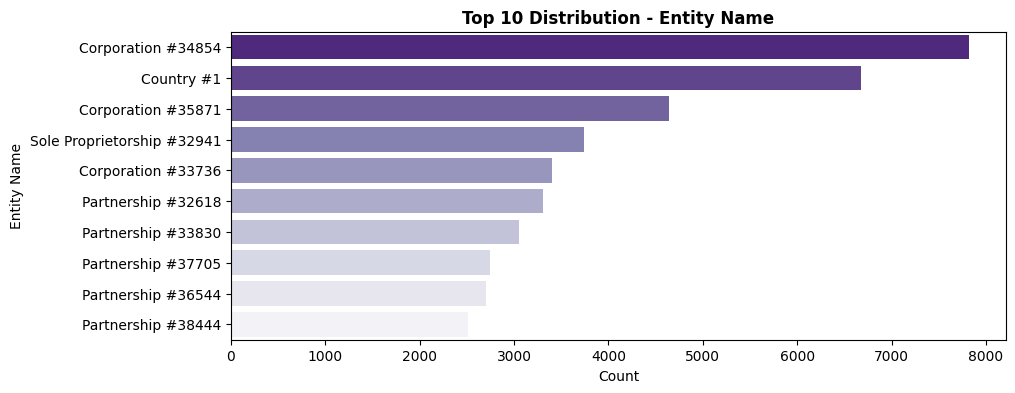

--------------------------------------------------


In [16]:
univariate_analysis(
    hi_small_accounts,
    categorical_cols=accounts_categorical_cols,
    numerical_cols=accounts_numerical_cols,
)

**Univariate analysis summary (Small Accounts):** `Bank Name` and `Entity Name` are broadly distributed across thousands of distinct entities without extreme single-category dominance. Accounts map to 5,177 unique `Bank ID` values.


### 4.2 Medium Accounts Dataset Exploration


In [17]:
# Load the HI-Medium and LI-Medium transaction datasets.
hi_medium_accounts = pd.read_csv(DATA_DIR / "HI-Medium_Accounts.csv")
li_medium_accounts = pd.read_csv(DATA_DIR / "LI-Medium_Accounts.csv")

In [18]:
display(inspect_dataset(hi_medium_accounts, dataset_name="HI-Medium Accounts"))
display(inspect_dataset(li_medium_accounts, dataset_name="LI-Medium Accounts"))

Inspection Report: HI-Medium Accounts
Dataset Shape: 2,087,786 rows × 5 columns


Duplicate Rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2087786 entries, 0 to 2087785
Data columns (total 5 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   Bank Name       object
 1   Bank ID         int64 
 2   Account Number  object
 3   Entity ID       object
 4   Entity Name     object
dtypes: int64(1), object(4)
memory usage: 79.6+ MB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Bank Name,object,0,0.0,80180,China Bank #561
Bank ID,int64,0,0.0,122333,53267
Account Number,object,0,0.0,2087762,817D00980
Entity ID,object,0,0.0,668138,2AA1F24F180
Entity Name,object,0,0.0,668138,Corporation #183669


Inspection Report: LI-Medium Accounts
Dataset Shape: 2,040,823 rows × 5 columns


Duplicate Rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2040823 entries, 0 to 2040822
Data columns (total 5 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   Bank Name       object
 1   Bank ID         int64 
 2   Account Number  object
 3   Entity ID       object
 4   Entity Name     object
dtypes: int64(1), object(4)
memory usage: 77.9+ MB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Bank Name,object,0,0.0,76636,Bank of New Orleans
Bank ID,int64,0,0.0,119617,9778
Account Number,object,0,0.0,2040789,834A31900
Entity ID,object,0,0.0,654133,2AA23456AF0
Entity Name,object,0,0.0,654133,Corporation #398


**Inspection summary (Medium Accounts):** HI-Medium Accounts contains 2,087,786 rows and LI-Medium Accounts contains 2,033,099 rows across 5 columns, with zero missing values or duplicate rows. All bank codes and account string formats remain intact.


=== Numerical Feature Summary ===


,Bank ID
count,2.087786e+06
mean,6.321024e+05
std,9.703746e+05
min,0.000000e+00
25%,3.962400e+04
50%,2.037290e+05
75%,3.812120e+05
max,3.225455e+06




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Bank Name**


Bank Name
Savings Bank of Indianapolis    5635
Savings Bank of Seattle         5575
First Bank of Plattsburg        4983
First Bank of Miami             4887
Bank of Miami                   4722
National Bank of Plattsburg     4610
National Bank of New Orleans    4557
Bank of Huron                   4542
Savings Bank of Newbury         4416
National Bank of Los Angeles    4264
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


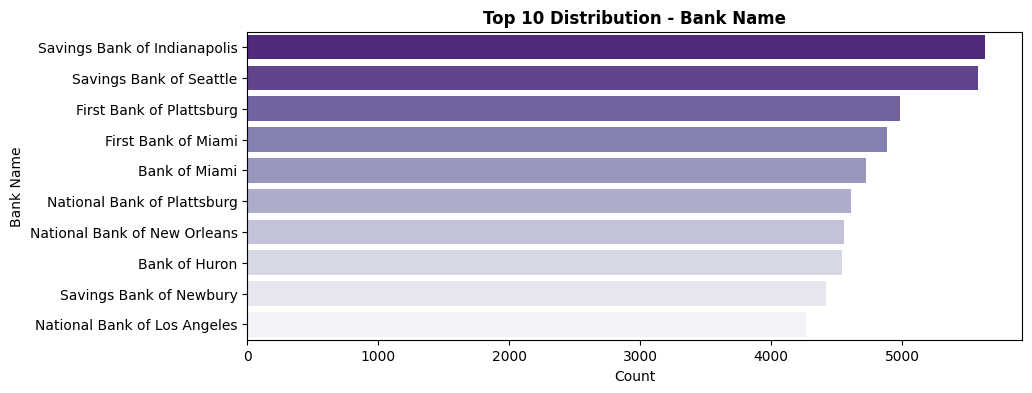

--------------------------------------------------

Top 10 Value Counts for: **Account Number**


Account Number
8347A1550    2
83B7523F0    2
8519125F0    2
81F71BE10    2
83FFDA200    2
83B745350    2
81A27EB30    2
80C7444D0    2
82954D380    2
851912640    2
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


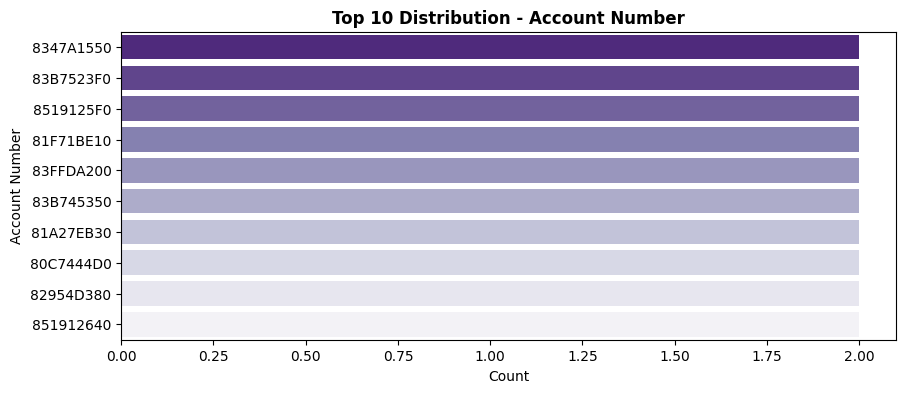

--------------------------------------------------

Top 10 Value Counts for: **Entity ID**


Entity ID
2AA1D8AEFB0    8638
2AA203253D0    5639
2AA208AC7D0    4738
2AA1FE77330    4714
2AA1E405CB0    4369
2AA2017EDA0    4237
2AA205E39A0    4078
2AA20022BD0    4058
2AA205E3730    3666
2AA1D8C69D0    3290
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


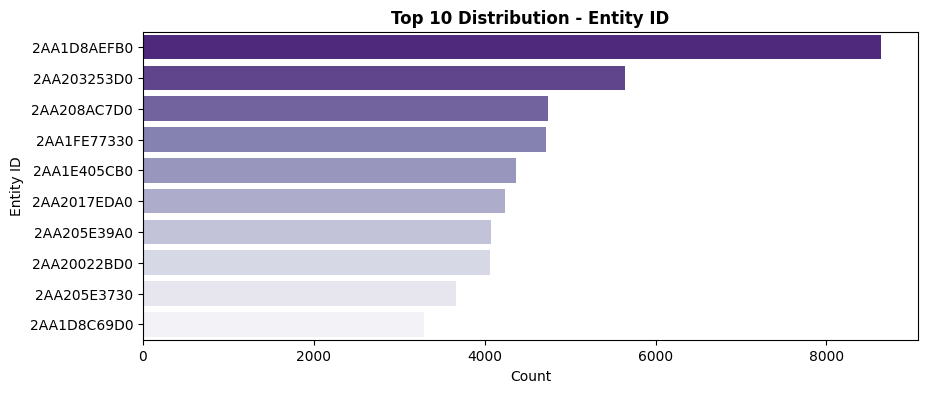

--------------------------------------------------

Top 10 Value Counts for: **Entity Name**


Entity Name
Corporation #140481            8638
Partnership #139664            5639
Country #1                     4738
Partnership #130756            4714
Sole Proprietorship #145836    4369
Corporation #132573            4237
Sole Proprietorship #144757    4078
Partnership #133653            4058
Corporation #139355            3666
Corporation #140482            3290
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


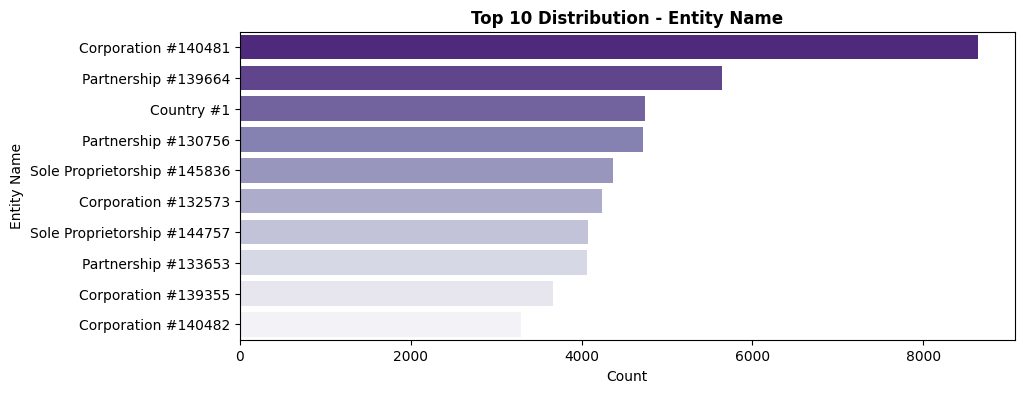

--------------------------------------------------


In [19]:
univariate_analysis(
    hi_medium_accounts,
    categorical_cols=accounts_categorical_cols,
    numerical_cols=accounts_numerical_cols,
)

**Univariate analysis summary (Medium Accounts):** Medium account datasets expand entity cardinality to over 20,400 distinct bank IDs while maintaining matching distributions with small account datasets.


## <span style="color: #9947dcff;">5. Patterns Dataset Analysis</span>


### 5.1 Small Patterns Dataset Exploration


In [20]:
def load_patterns_file(filepath):
    """
    Parses pattern .txt files containing laundering attempt metadata lines and transaction records.
    """
    records = []
    current_pattern = None
    columns = [
        "Timestamp",
        "From Bank",
        "Account",
        "To Bank",
        "Account.1",
        "Amount Received",
        "Receiving Currency",
        "Amount Paid",
        "Payment Currency",
        "Payment Format",
        "Is Laundering",
    ]
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line_str = line.strip()
            if not line_str:
                continue
            if line_str.startswith("BEGIN LAUNDERING ATTEMPT"):
                parts = line_str.split("-", 1)
                if len(parts) > 1:
                    current_pattern = parts[1].split(":")[0].strip()
                else:
                    current_pattern = "UNKNOWN"
            elif line_str.startswith("END LAUNDERING ATTEMPT"):
                current_pattern = None
            else:
                fields = line_str.split(",")
                if len(fields) == 11:
                    rec = dict(zip(columns, fields))
                    rec["Pattern Type"] = current_pattern
                    records.append(rec)
    df = pd.DataFrame(records)
    numeric_cols = ["From Bank", "To Bank", "Amount Received", "Amount Paid", "Is Laundering"]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col])
    return df

# Load the HI-Small and LI-Small patterns datasets.
hi_small_patterns = load_patterns_file(DATA_DIR / "HI-Small_Patterns.txt")
li_small_patterns = load_patterns_file(DATA_DIR / "LI-Small_Patterns.txt")

In [21]:
# Patterns datasets share the transaction schema with an additional Pattern Type metadata column.
patterns_categorical_cols = [
    "Account",
    "Account.1",
    "Receiving Currency",
    "Payment Currency",
    "Payment Format",
    "Is Laundering",  # Binary target
    "Pattern Type",
]

patterns_numerical_cols = [
    "From Bank",
    "To Bank",
    "Amount Received",
    "Amount Paid",
]

# Timestamp is temporal, so keep it separate from categorical and numerical features.
patterns_datetime_cols = ["Timestamp"]

In [22]:
display(inspect_dataset(hi_small_patterns, dataset_name="HI-Small Patterns"))

Inspection Report: HI-Small Patterns
Dataset Shape: 3,209 rows × 12 columns


Duplicate Rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3209 entries, 0 to 3208
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Timestamp           3209 non-null   object 
 1   From Bank           3209 non-null   int64  
 2   Account             3209 non-null   object 
 3   To Bank             3209 non-null   int64  
 4   Account.1           3209 non-null   object 
 5   Amount Received     3209 non-null   float64
 6   Receiving Currency  3209 non-null   object 
 7   Amount Paid         3209 non-null   float64
 8   Payment Currency    3209 non-null   object 
 9   Payment Format      3209 non-null   object 
 10  Is Laundering       3209 non-null   int64  
 11  Pattern Type        3209 non-null   object 
dtypes: float64(2), int64(3), object(7)
memory usage: 301.0+ KB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Timestamp,object,0,0.0,2888,2022/09/01 00:06
From Bank,int64,0,0.0,775,21174
Account,object,0,0.0,2071,800737690
To Bank,int64,0,0.0,775,12
Account.1,object,0,0.0,2064,80011F990
Amount Received,float64,0,0.0,3145,2848.96
Receiving Currency,object,0,0.0,15,Euro
Amount Paid,float64,0,0.0,3145,2848.96
Payment Currency,object,0,0.0,15,Euro
Payment Format,object,0,0.0,2,ACH


**Inspection summary (HI-Small Patterns):** HI-Small Patterns contains 3,209 rows and 12 columns with zero missing values and zero duplicate rows. 100% of rows are positive laundering cases (`Is Laundering = 1`).


In [23]:
hi_small_patterns["Timestamp"] = pd.to_datetime(hi_small_patterns["Timestamp"])
li_small_patterns["Timestamp"] = pd.to_datetime(li_small_patterns["Timestamp"])

=== Numerical Feature Summary ===


,From Bank,To Bank,Amount Received,Amount Paid
count,3209.000000,3209.000000,3.209000e+03,3.209000e+03
mean,48183.410408,43492.580866,2.720119e+06,2.720119e+06
std,74829.473399,68920.136412,5.285722e+07,5.285722e+07
min,1.000000,1.000000,3.702870e-01,3.702870e-01
25%,1267.000000,1024.000000,5.949730e+03,5.949730e+03
50%,13969.000000,14325.000000,1.257693e+04,1.257693e+04
75%,39198.000000,31208.000000,2.057176e+04,2.057176e+04
max,251264.000000,251264.000000,2.597164e+09,2.597164e+09




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Account**


Account
80266F880    29
812D22980    25
811C599A0    21
8021353D0    21
811C597B0    21
812A09D40    18
811B83280    17
812D0C3C0    17
811B6E170    17
808338D40    16
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


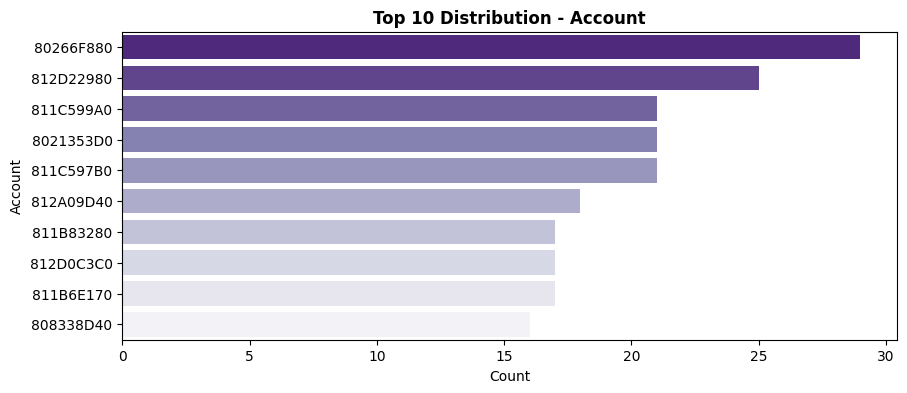

--------------------------------------------------

Top 10 Value Counts for: **Account.1**


Account.1
811C599A0    31
8021353D0    28
811C597B0    23
80266F880    22
811ED7DF0    20
812A09CF0    19
811D80C30    18
811B83280    17
8079DDC30    16
8028F2650    16
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


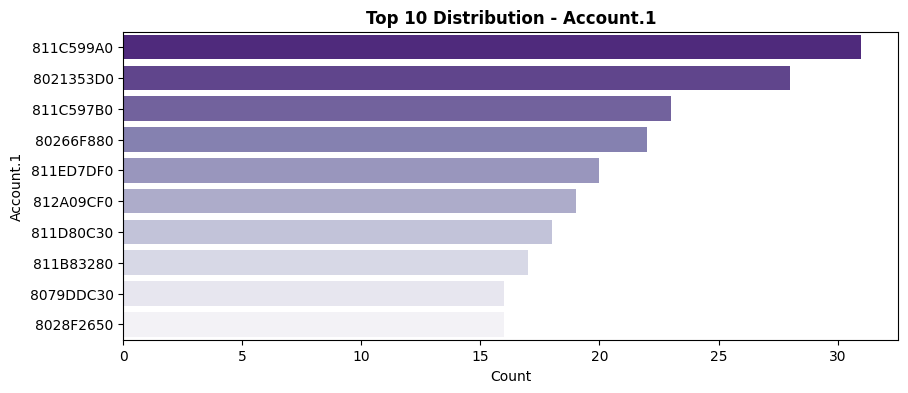

--------------------------------------------------

Top 10 Value Counts for: **Receiving Currency**


Receiving Currency
US Dollar          1178
Euro                886
Saudi Riyal         336
Swiss Franc         114
Rupee               111
Yuan                107
Yen                  89
Canadian Dollar      76
Ruble                72
UK Pound             71
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


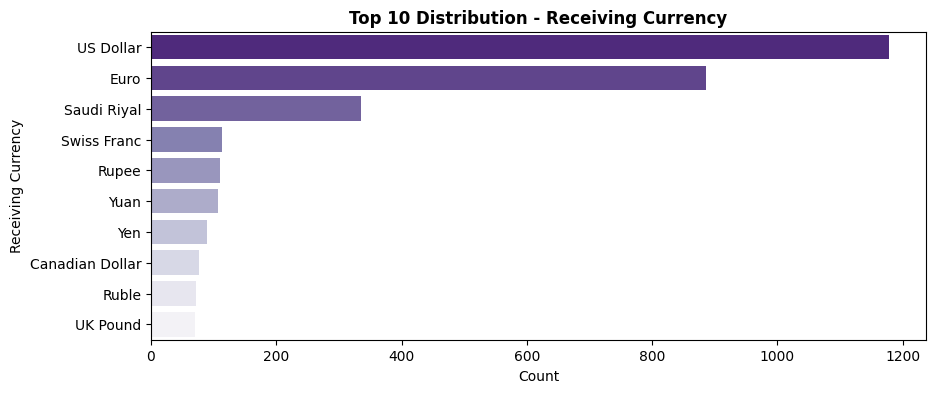

--------------------------------------------------

Top 10 Value Counts for: **Payment Currency**


Payment Currency
US Dollar          1178
Euro                886
Saudi Riyal         336
Swiss Franc         114
Rupee               111
Yuan                107
Yen                  89
Canadian Dollar      76
Ruble                72
UK Pound             71
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


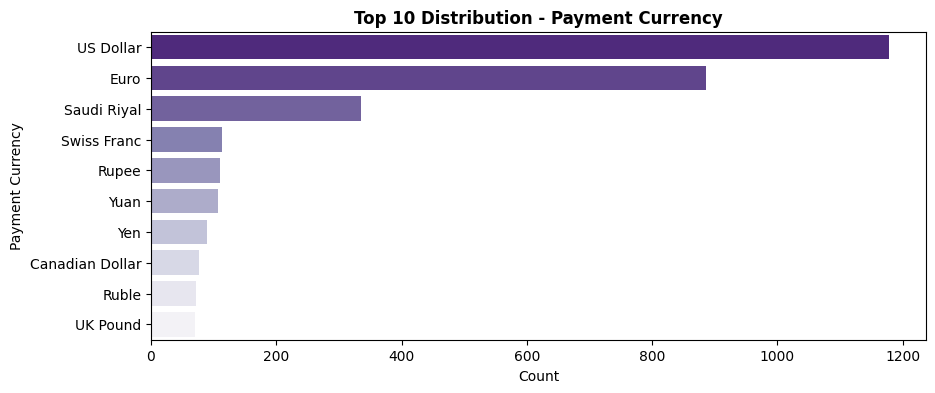

--------------------------------------------------

Top 10 Value Counts for: **Payment Format**


Payment Format
ACH        3208
Bitcoin       1
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


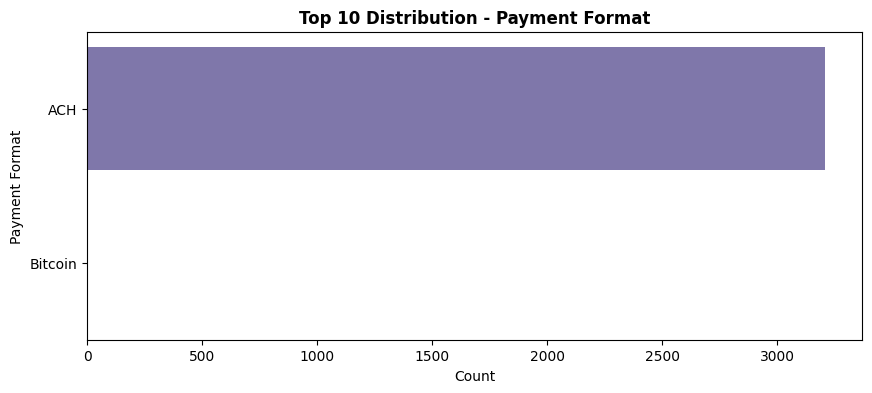

--------------------------------------------------

Top 10 Value Counts for: **Is Laundering**


Is Laundering
1    3209
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


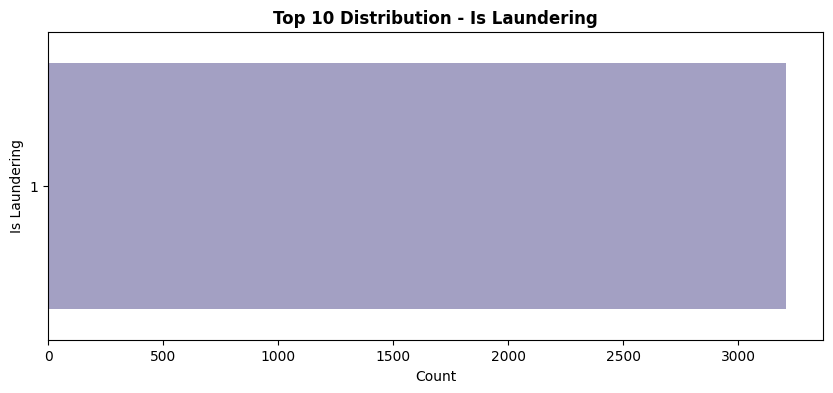

--------------------------------------------------

Top 10 Value Counts for: **Pattern Type**


Pattern Type
GATHER-SCATTER    716
SCATTER-GATHER    626
STACK             466
FAN-OUT           342
FAN-IN            318
CYCLE             287
BIPARTITE         263
RANDOM            191
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


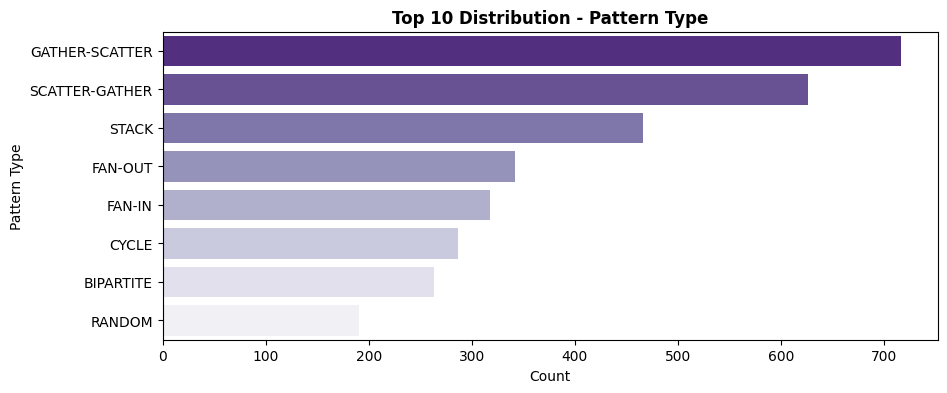

--------------------------------------------------


In [24]:
univariate_analysis(
    hi_small_patterns,
    categorical_cols=patterns_categorical_cols,
    numerical_cols=patterns_numerical_cols,
    datetime_cols=patterns_datetime_cols,
)

**Univariate analysis summary (HI-Small Patterns):** Suspicious sequences span 8 distinct laundering topologies, led by `GATHER-SCATTER` (716 rows), `SCATTER-GATHER` (626 rows), `STACK` (466 rows), `FAN-OUT` (342 rows), `FAN-IN` (318 rows), and `CYCLE` (287 rows).


In [25]:
display(inspect_dataset(li_small_patterns, dataset_name="LI-Small Patterns"))

Inspection Report: LI-Small Patterns
Dataset Shape: 1,023 rows × 12 columns


Duplicate Rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1023 entries, 0 to 1022
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Timestamp           1023 non-null   datetime64[ns]
 1   From Bank           1023 non-null   int64         
 2   Account             1023 non-null   object        
 3   To Bank             1023 non-null   int64         
 4   Account.1           1023 non-null   object        
 5   Amount Received     1023 non-null   float64       
 6   Receiving Currency  1023 non-null   object        
 7   Amount Paid         1023 non-null   float64       
 8   Payment Currency    1023 non-null   object        
 9   Payment Format      1023 non-null   object        
 10  Is Laundering       1023 non-null   int64         
 11  Pattern Type        1023 non-null   object        
dtypes: datet

,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Timestamp,datetime64[ns],0,0.0,983,2022-09-01 02:38:00
From Bank,int64,0,0.0,189,1812
Account,object,0,0.0,712,80279F810
To Bank,int64,0,0.0,196,110
Account.1,object,0,0.0,804,8000A94C0
Amount Received,float64,0,0.0,981,10154.74
Receiving Currency,object,0,0.0,15,Australian Dollar
Amount Paid,float64,0,0.0,981,10154.74
Payment Currency,object,0,0.0,15,Australian Dollar
Payment Format,object,0,0.0,2,ACH


**Inspection summary (LI-Small Patterns):** LI-Small Patterns contains 1,023 rows and 12 columns with zero missing values or duplicate rows. All records have `Is Laundering = 1`.


=== Numerical Feature Summary ===


,From Bank,To Bank,Amount Received,Amount Paid
count,1023.000000,1023.000000,1.023000e+03,1.023000e+03
mean,9685.884653,11114.734115,3.921572e+06,3.921572e+06
std,28795.301049,31987.075561,6.716403e+07,6.716403e+07
min,0.000000,0.000000,6.000000e-02,6.000000e-02
25%,20.000000,20.000000,4.311585e+03,4.311585e+03
50%,1217.000000,1231.000000,9.175320e+03,9.175320e+03
75%,11047.000000,11495.000000,1.471589e+04,1.471589e+04
max,238669.000000,249331.000000,1.927898e+09,1.927898e+09




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Account**


Account
800603DB0    16
800077210    16
80060B3A0    15
8004943A0    15
800701D70    15
800134F30    14
80BF623F0    14
805756EB0    13
800774890    13
8001F2990    12
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


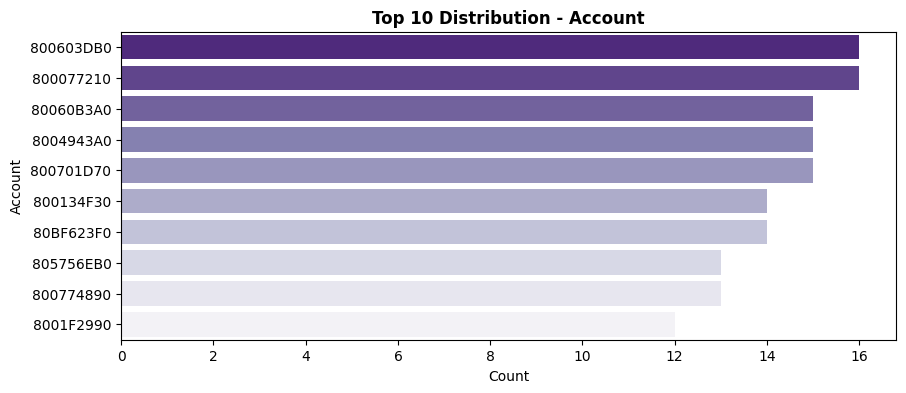

--------------------------------------------------

Top 10 Value Counts for: **Account.1**


Account.1
80025E130    16
800A08E20    15
8012FC120    15
80021A8B0    14
80219F420    13
800AF0650    13
800299A70    12
800127B30    11
800130E70    10
80151E540    10
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


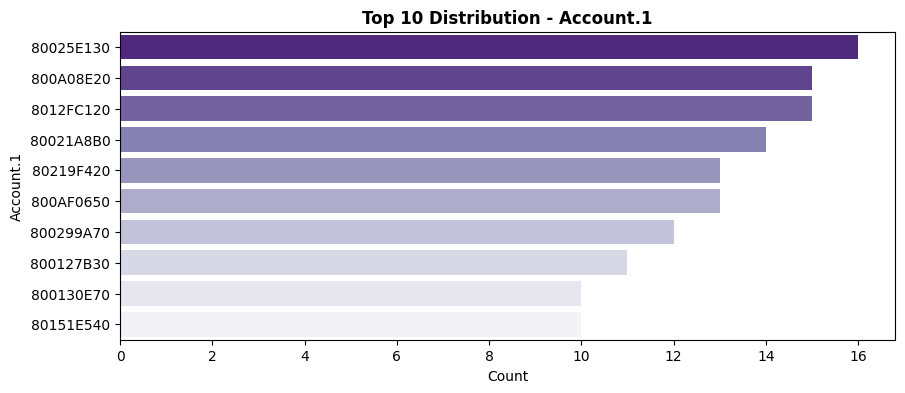

--------------------------------------------------

Top 10 Value Counts for: **Receiving Currency**


Receiving Currency
US Dollar            541
Euro                 414
Yuan                  19
Yen                   12
Australian Dollar     11
Canadian Dollar        7
Swiss Franc            4
Brazil Real            3
Rupee                  3
Saudi Riyal            2
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


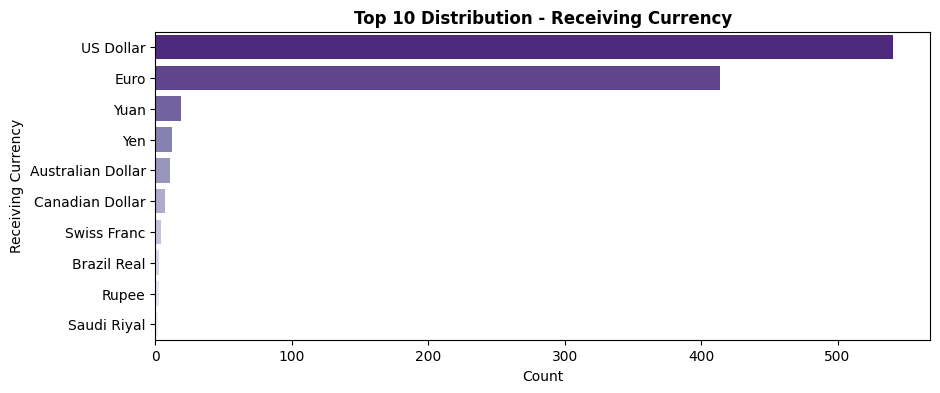

--------------------------------------------------

Top 10 Value Counts for: **Payment Currency**


Payment Currency
US Dollar            541
Euro                 414
Yuan                  19
Yen                   12
Australian Dollar     11
Canadian Dollar        7
Swiss Franc            4
Brazil Real            3
Rupee                  3
Saudi Riyal            2
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


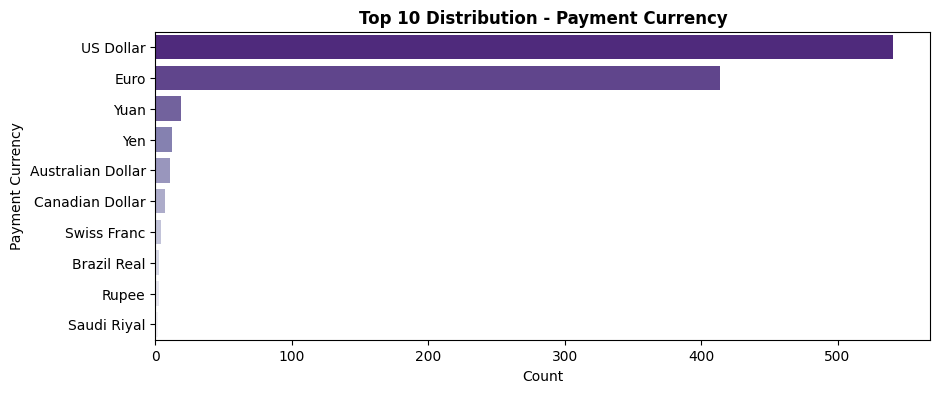

--------------------------------------------------

Top 10 Value Counts for: **Payment Format**


Payment Format
ACH        1022
Bitcoin       1
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


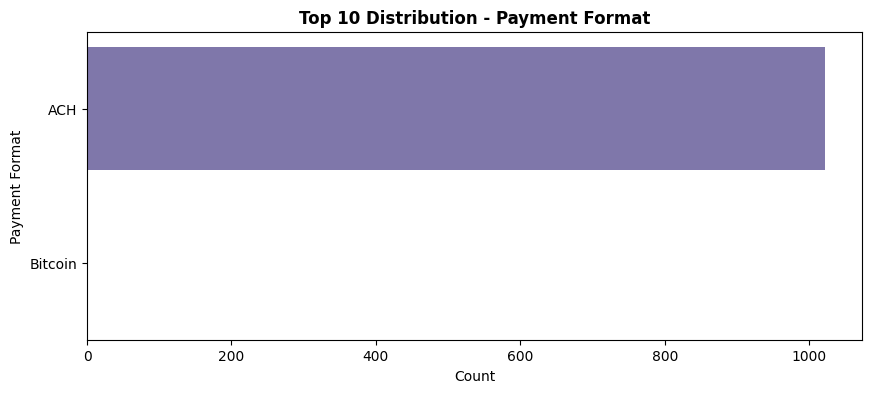

--------------------------------------------------

Top 10 Value Counts for: **Is Laundering**


Is Laundering
1    1023
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


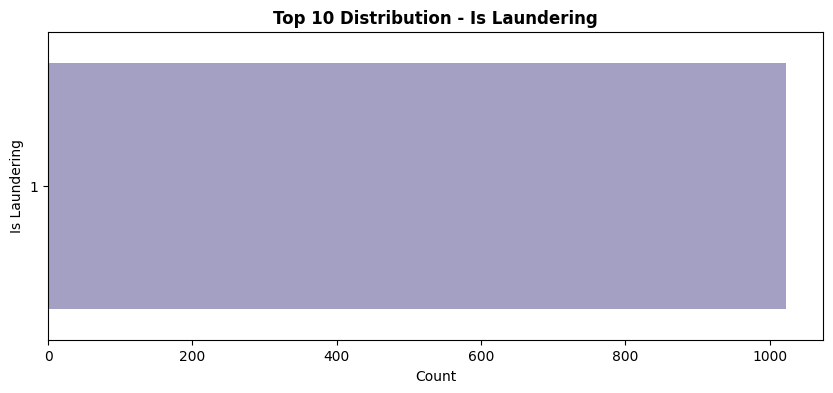

--------------------------------------------------

Top 10 Value Counts for: **Pattern Type**


Pattern Type
SCATTER-GATHER    182
STACK             180
GATHER-SCATTER    150
FAN-OUT           149
BIPARTITE         129
CYCLE              83
RANDOM             77
FAN-IN             73
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


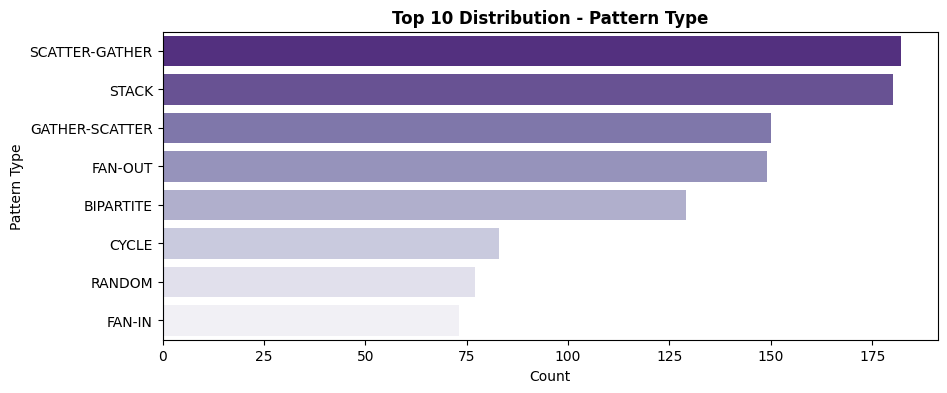

--------------------------------------------------


In [26]:
univariate_analysis(
    li_small_patterns,
    categorical_cols=patterns_categorical_cols,
    numerical_cols=patterns_numerical_cols,
    datetime_cols=patterns_datetime_cols,
)

**Univariate analysis summary (LI-Small Patterns):** Topologies are dominated by `SCATTER-GATHER` (182 rows), `STACK` (180 rows), and `GATHER-SCATTER` (150 rows), confirming matching pattern structures between small sources.


### 5.2 Medium Patterns Dataset Exploration


In [27]:
# Load the HI-Medium and LI-Medium patterns datasets.
hi_medium_patterns = load_patterns_file(DATA_DIR / "HI-Medium_Patterns.txt")
li_medium_patterns = load_patterns_file(DATA_DIR / "LI-Medium_Patterns.txt")

In [28]:
display(inspect_dataset(hi_medium_patterns, dataset_name="HI-Medium Patterns"))
display(inspect_dataset(li_medium_patterns, dataset_name="LI-Medium Patterns"))

Inspection Report: HI-Medium Patterns
Dataset Shape: 22,743 rows × 12 columns


Duplicate Rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22743 entries, 0 to 22742
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Timestamp           22743 non-null  object 
 1   From Bank           22743 non-null  int64  
 2   Account             22743 non-null  object 
 3   To Bank             22743 non-null  int64  
 4   Account.1           22743 non-null  object 
 5   Amount Received     22743 non-null  float64
 6   Receiving Currency  22743 non-null  object 
 7   Amount Paid         22743 non-null  float64
 8   Payment Currency    22743 non-null  object 
 9   Payment Format      22743 non-null  object 
 10  Is Laundering       22743 non-null  int64  
 11  Pattern Type        22743 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 2.1+ MB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Timestamp,object,0,0.0,14703,2022/09/01 05:14
From Bank,int64,0,0.0,2351,952
Account,object,0,0.0,14836,8139F54E0
To Bank,int64,0,0.0,2343,111632
Account.1,object,0,0.0,14546,8062C56E0
Amount Received,float64,0,0.0,21886,5331.44
Receiving Currency,object,0,0.0,15,US Dollar
Amount Paid,float64,0,0.0,21886,5331.44
Payment Currency,object,0,0.0,15,US Dollar
Payment Format,object,0,0.0,2,ACH


Inspection Report: LI-Medium Patterns
Dataset Shape: 3,909 rows × 12 columns


Duplicate Rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3909 entries, 0 to 3908
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Timestamp           3909 non-null   object 
 1   From Bank           3909 non-null   int64  
 2   Account             3909 non-null   object 
 3   To Bank             3909 non-null   int64  
 4   Account.1           3909 non-null   object 
 5   Amount Received     3909 non-null   float64
 6   Receiving Currency  3909 non-null   object 
 7   Amount Paid         3909 non-null   float64
 8   Payment Currency    3909 non-null   object 
 9   Payment Format      3909 non-null   object 
 10  Is Laundering       3909 non-null   int64  
 11  Pattern Type        3909 non-null   object 
dtypes: float64(2), int64(3), object(7)
memory usage: 366.6+ KB


,Data Type,Missing Values,Missing (%),Unique Values,Sample Value
Timestamp,object,0,0.0,3592,2022/09/01 00:29
From Bank,int64,0,0.0,1228,110994
Account,object,0,0.0,2719,80A0ECCF0
To Bank,int64,0,0.0,1241,110320
Account.1,object,0,0.0,2821,804F34520
Amount Received,float64,0,0.0,3767,311.9
Receiving Currency,object,0,0.0,14,Euro
Amount Paid,float64,0,0.0,3767,311.9
Payment Currency,object,0,0.0,14,Euro
Payment Format,object,0,0.0,2,ACH


**Inspection summary (Medium Patterns):** HI-Medium Patterns has 22,743 rows and LI-Medium Patterns has 3,909 rows (12 columns each) with zero missing values or duplicates. All 26,652 medium pattern rows are positive laundering cases.


In [29]:
hi_medium_patterns["Timestamp"] = pd.to_datetime(hi_medium_patterns["Timestamp"])
li_medium_patterns["Timestamp"] = pd.to_datetime(li_medium_patterns["Timestamp"])

=== Numerical Feature Summary ===


,From Bank,To Bank,Amount Received,Amount Paid
count,2.274300e+04,2.274300e+04,2.274300e+04,2.274300e+04
mean,1.015611e+05,9.771266e+04,7.331469e+07,7.331469e+07
std,2.180535e+05,2.014809e+05,6.196314e+09,6.196314e+09
min,0.000000e+00,0.000000e+00,1.110412e+00,1.110412e+00
25%,5.610000e+03,5.665000e+03,5.825595e+03,5.825595e+03
50%,2.550700e+04,2.564000e+04,1.152275e+04,1.152275e+04
75%,1.514690e+05,1.502240e+05,1.835655e+04,1.835655e+04
max,2.131507e+06,2.181233e+06,9.062701e+11,9.062701e+11




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Account**


Account
81C393430    46
81BBEA160    43
83000D0D0    33
824BF4150    31
83000CE40    30
800ED43D0    29
81C387B50    27
803C25F20    27
81ACBE4A0    27
804682F80    27
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


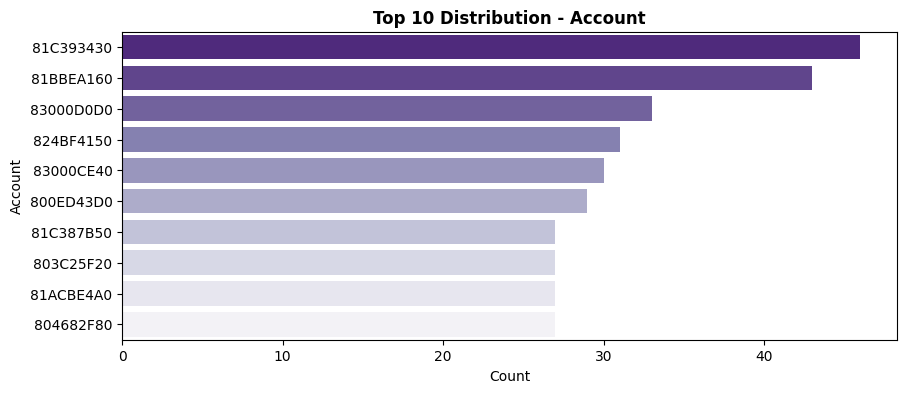

--------------------------------------------------

Top 10 Value Counts for: **Account.1**


Account.1
81C393430    45
81BBEA160    41
824BF8940    40
800ED43D0    37
824BF4150    28
81ACBE4A0    27
81E25E8A0    26
8038DA860    26
823DD3180    26
823D33310    25
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


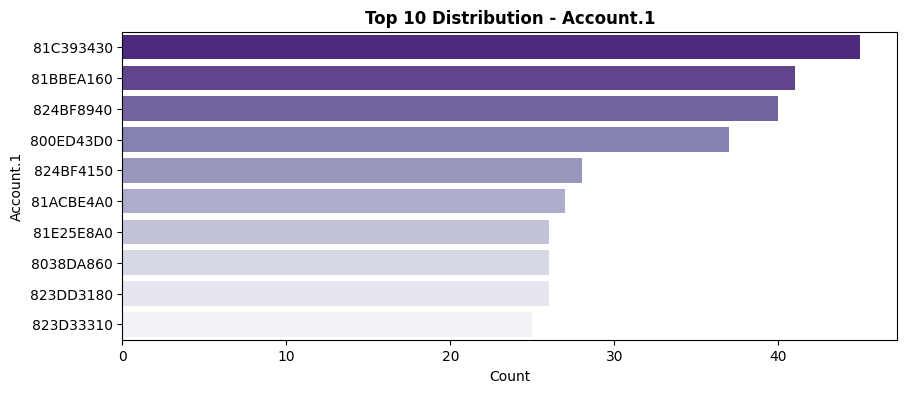

--------------------------------------------------

Top 10 Value Counts for: **Receiving Currency**


Receiving Currency
US Dollar            9714
Euro                 6792
Yuan                 1882
UK Pound             1262
Ruble                1087
Yen                   819
Rupee                 552
Australian Dollar     341
Canadian Dollar       141
Shekel                114
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


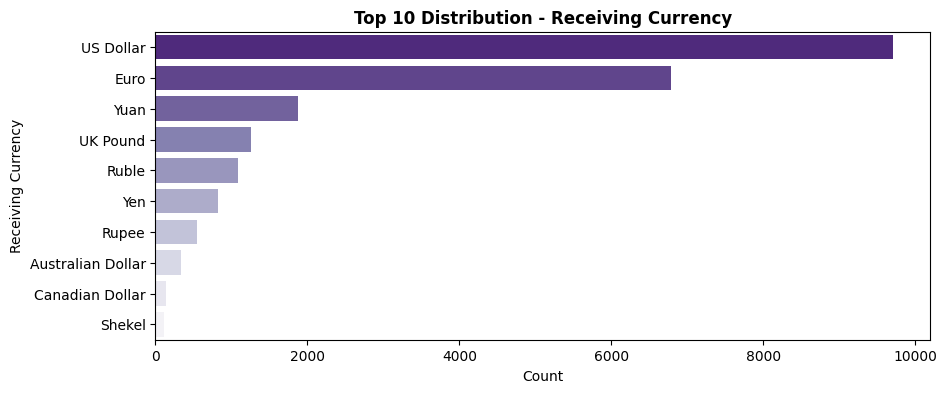

--------------------------------------------------

Top 10 Value Counts for: **Payment Currency**


Payment Currency
US Dollar            9714
Euro                 6792
Yuan                 1882
UK Pound             1262
Ruble                1087
Yen                   819
Rupee                 552
Australian Dollar     341
Canadian Dollar       141
Shekel                114
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


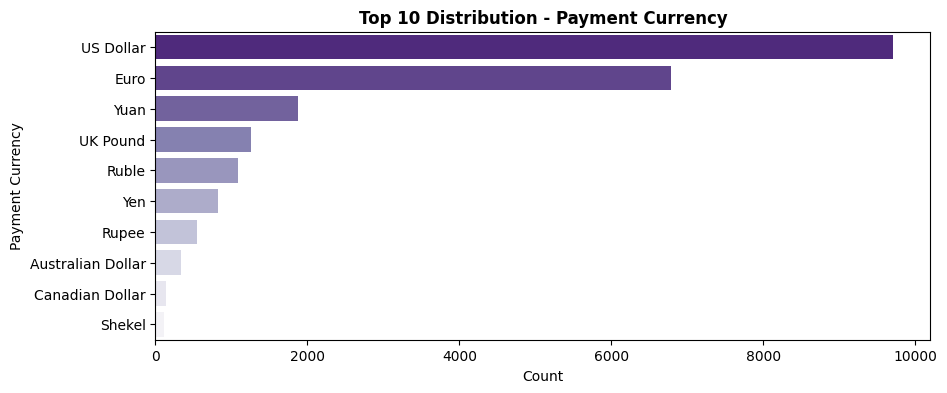

--------------------------------------------------

Top 10 Value Counts for: **Payment Format**


Payment Format
ACH        22740
Bitcoin        3
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


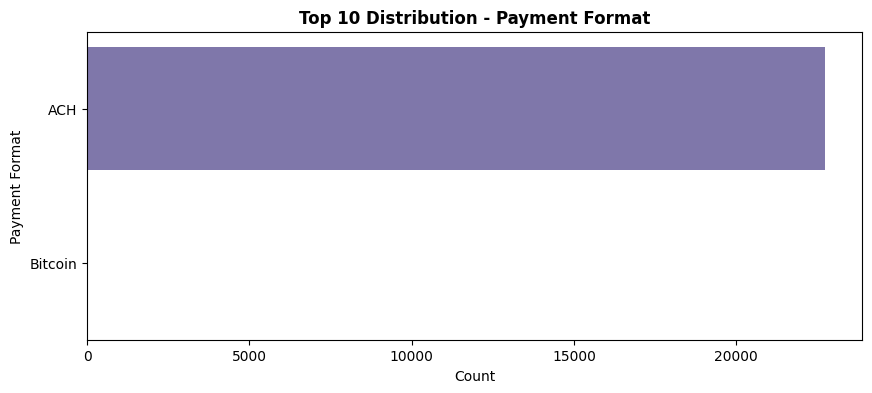

--------------------------------------------------

Top 10 Value Counts for: **Is Laundering**


Is Laundering
1    22743
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


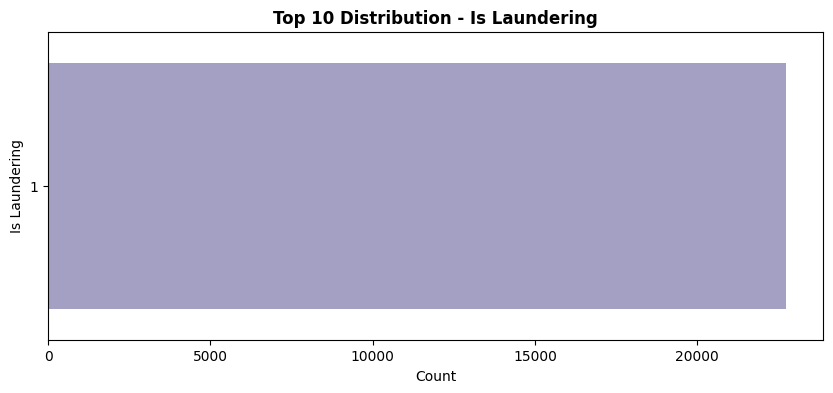

--------------------------------------------------

Top 10 Value Counts for: **Pattern Type**


Pattern Type
GATHER-SCATTER    4289
SCATTER-GATHER    3988
STACK             3986
FAN-IN            2315
CYCLE             2235
BIPARTITE         2135
FAN-OUT           2128
RANDOM            1667
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


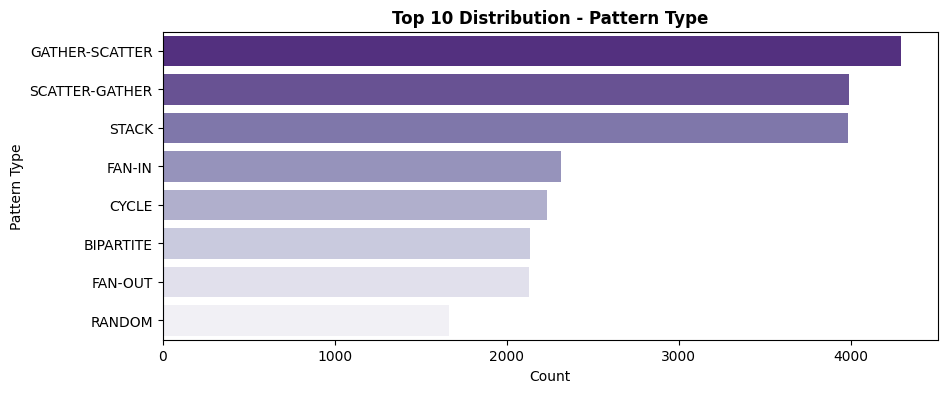

--------------------------------------------------


In [30]:
univariate_analysis(
    hi_medium_patterns,
    categorical_cols=patterns_categorical_cols,
    numerical_cols=patterns_numerical_cols,
    datetime_cols=patterns_datetime_cols,
)

**Univariate analysis summary (HI-Medium Patterns):** Patterns are heavily concentrated in multi-hop structures: `GATHER-SCATTER` (4,289), `SCATTER-GATHER` (3,988), `STACK` (3,986), `FAN-IN` (2,315), `CYCLE` (2,235), `BIPARTITE` (2,135), and `FAN-OUT` (2,128).


=== Numerical Feature Summary ===


,From Bank,To Bank,Amount Received,Amount Paid
count,3.909000e+03,3.909000e+03,3.909000e+03,3.909000e+03
mean,1.054753e+05,1.198013e+05,5.149007e+07,5.149007e+07
std,2.428259e+05,2.855430e+05,1.335281e+09,1.335281e+09
min,0.000000e+00,0.000000e+00,1.500000e-01,1.500000e-01
25%,3.613000e+03,3.358000e+03,6.032410e+03,6.032410e+03
50%,2.570400e+04,2.636100e+04,1.187990e+04,1.187990e+04
75%,1.342620e+05,1.428680e+05,1.952677e+04,1.952677e+04
max,2.127559e+06,2.127559e+06,5.301076e+10,5.301076e+10




=== Categorical Feature Distributions ===

Top 10 Value Counts for: **Account**


Account
80775E4D0    16
818B29B40    16
81C19FF10    16
803C89370    16
8201544E0    16
80E2D9180    16
816F8C090    16
829353B50    16
8006C7D30    16
8135D5100    16
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


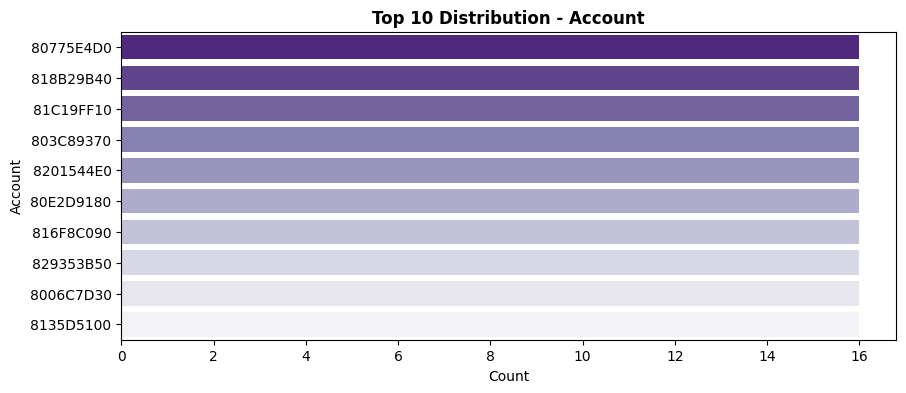

--------------------------------------------------

Top 10 Value Counts for: **Account.1**


Account.1
811AA7500    16
8092E7170    16
823463460    16
812EB11A0    16
811C2D520    16
806433D10    15
8022AC190    15
806F30B30    15
8052FA290    15
800DFBBE0    15
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


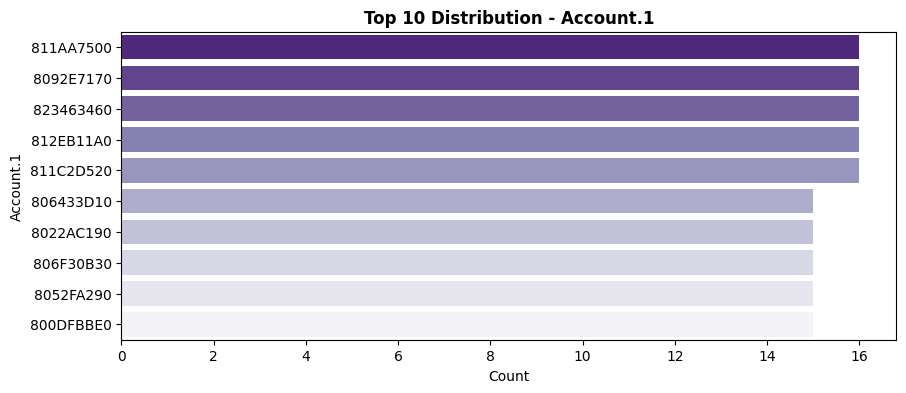

--------------------------------------------------

Top 10 Value Counts for: **Receiving Currency**


Receiving Currency
US Dollar            1560
Euro                 1225
Yuan                  229
Yen                   203
Ruble                 197
Rupee                 170
Canadian Dollar       115
UK Pound              110
Australian Dollar      58
Shekel                 38
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


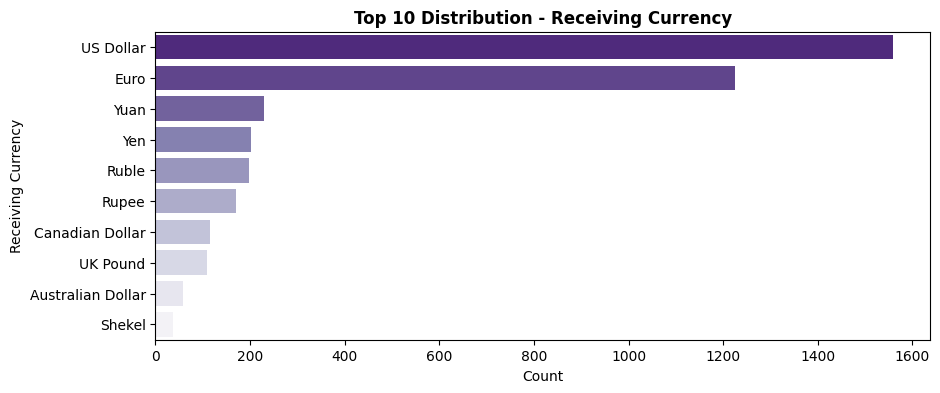

--------------------------------------------------

Top 10 Value Counts for: **Payment Currency**


Payment Currency
US Dollar            1560
Euro                 1225
Yuan                  229
Yen                   203
Ruble                 197
Rupee                 170
Canadian Dollar       115
UK Pound              110
Australian Dollar      58
Shekel                 38
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


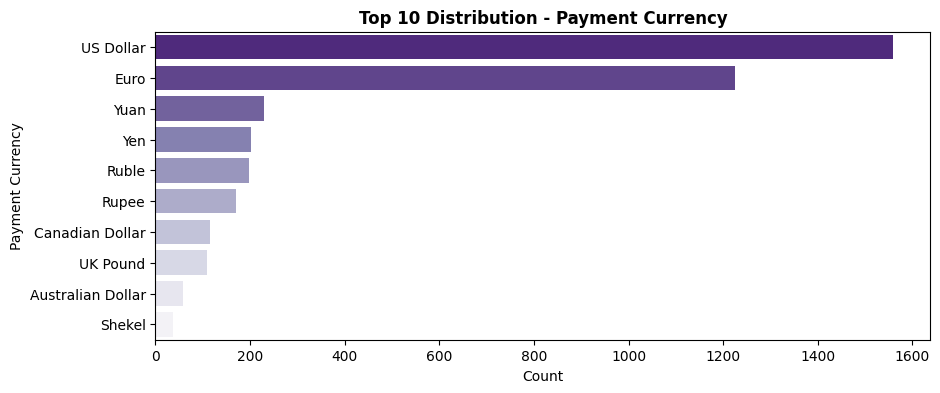

--------------------------------------------------

Top 10 Value Counts for: **Payment Format**


Payment Format
ACH        3908
Bitcoin       1
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


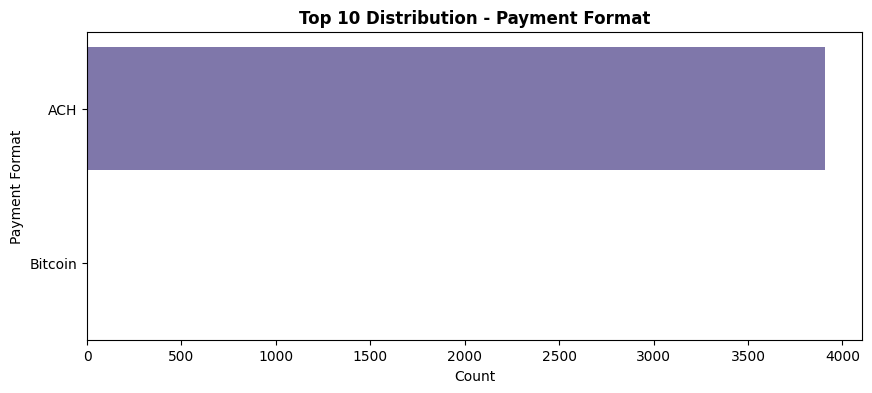

--------------------------------------------------

Top 10 Value Counts for: **Is Laundering**


Is Laundering
1    3909
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


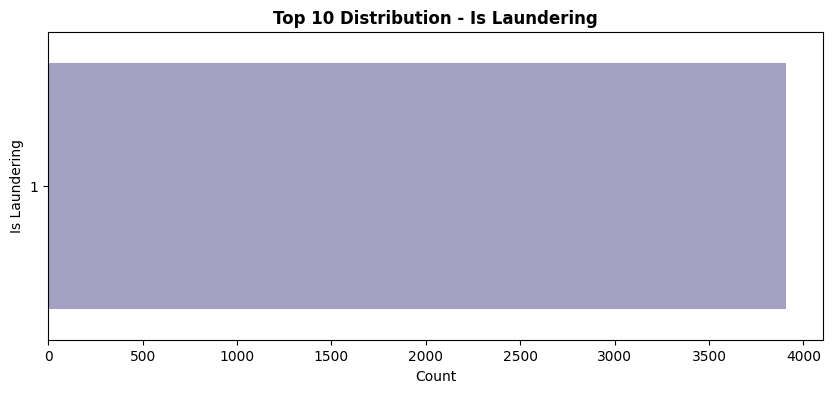

--------------------------------------------------

Top 10 Value Counts for: **Pattern Type**


Pattern Type
SCATTER-GATHER    886
STACK             615
GATHER-SCATTER    541
FAN-OUT           489
BIPARTITE         488
FAN-IN            329
CYCLE             283
RANDOM            278
Name: count, dtype: int64

C:\Users\almad\AppData\Local\Temp\ipykernel_17736\912119016.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


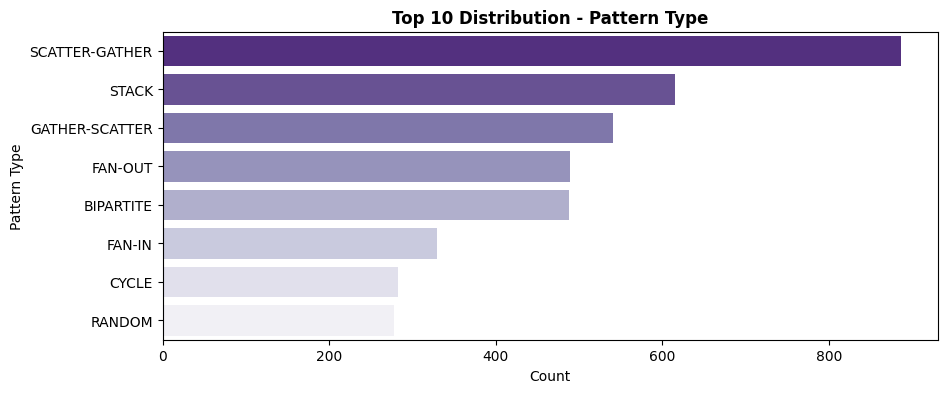

--------------------------------------------------


In [31]:
univariate_analysis(
    li_medium_patterns,
    categorical_cols=patterns_categorical_cols,
    numerical_cols=patterns_numerical_cols,
    datetime_cols=patterns_datetime_cols,
)

**Univariate analysis summary (LI-Medium Patterns):** LI-Medium patterns reinforce the topological distribution, adding 3,909 verified laundering sequences across currencies and payment formats.


### 5.3 Insights and Future Steps

**Synthesis of EDA Findings across Transactions, Accounts, and Patterns:**
1. **Transactions (Section 3):** Transaction logs contain over 10 million transfers with severe class imbalance (<0.1% laundering). Transfers occur across 7 payment formats (ACH, Wire, Cheque, Cash, Credit Card, Reinvestment, Bitcoin) and 15 currencies, requiring normalized amount conversion and temporal feature extraction.
2. **Accounts (Section 4):** Account metadata provides entity mappings across thousands of bank IDs. Identifier string columns (`Account Number`, `Entity ID`) must remain string-formatted to ensure exact sender/receiver left-joins.
3. **Patterns (Section 5):** The patterns dataset provides 30,884 verified laundering sequence records across 8 explicit graph topologies (GATHER-SCATTER, SCATTER-GATHER, STACK, FAN-OUT, FAN-IN, CYCLE, BIPARTITE, and RANDOM). Because all pattern rows are positive laundering examples (`Is Laundering = 1`), they must **not** be directly concatenated into training transaction sets as standard rows (which would corrupt class balance). Instead, pattern topology characteristics guide feature engineering.

**Next Preprocessing & Feature Engineering Steps:**
- **Account Linking:** Perform string-normalized left-joins between transaction sender/receiver accounts and the accounts table on (`Type`, `Bank ID`, `Account Number`).
- **Graph & Sequence Feature Derivation:** Engineer topological graph features based on the 8 identified pattern structures:
  - *In-degree & Out-degree Velocity:* Measure fan-in and fan-out activity per account over 1-hour, 24-hour, and 7-day rolling windows.
  - *Gather-Scatter & Cycle Detection:* Track rapid forward transfer ratios (amount paid / amount received) and circular transfer paths.
  - *Counterparty Diversity:* Calculate distinct counterparty entity counts for senders and receivers.
- **Class Balance Preservation:** Retain the true severely imbalanced transaction sampling for model training, applying specialized loss functions (e.g. Focal Loss, weighted Cross-Entropy) and precision-recall evaluation.


## <span style="color: #9947dcff;">6. Transaction Volume Velocity Over Time</span>

Inspecting transaction timestamps to detect minutely, hourly, and velocity patterns across dataset sources.


In [32]:
# Inspect timestamp range for HI-Small and LI-Small transaction datasets.
print("HI-Small timestamp range:", hi_small_trans['Timestamp'].min(), "to", hi_small_trans['Timestamp'].max()) 
print("LI-Small timestamp range:", li_small_trans['Timestamp'].min(), "to", li_small_trans['Timestamp'].max())

HI-Small timestamp range: 2022-09-01 00:00:00 to 2022-09-18 16:18:00
LI-Small timestamp range: 2022-09-01 00:00:00 to 2022-09-17 15:28:00


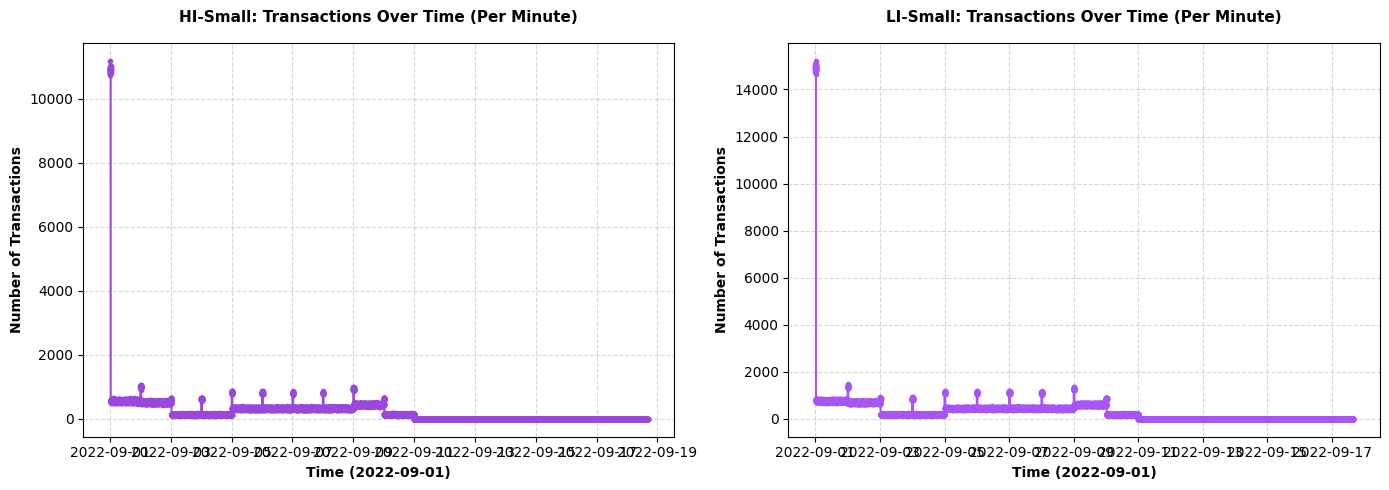

In [33]:
import matplotlib.pyplot as plt
import pandas as pd


# Resample transaction counts by 1-minute intervals
hi_minutely = hi_small_trans.set_index('Timestamp').resample('min').size()
li_minutely = li_small_trans.set_index('Timestamp').resample('min').size()

# Create side-by-side comparative volume velocity plots
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: HI-Small transaction velocity
ax[0].plot(hi_minutely.index, hi_minutely.values, color='#9947dc', linewidth=1.5, marker='o', markersize=3)
ax[0].set_title('HI-Small: Transactions Over Time (Per Minute)', fontsize=11, fontweight='bold', pad=15)
ax[0].set_xlabel('Time (2022-09-01)', fontsize=10, fontweight='bold')
ax[0].set_ylabel('Number of Transactions', fontsize=10, fontweight='bold')
ax[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: LI-Small transaction velocity
ax[1].plot(li_minutely.index, li_minutely.values, color='#a855f7', linewidth=1.5, marker='o', markersize=3)
ax[1].set_title('LI-Small: Transactions Over Time (Per Minute)', fontsize=11, fontweight='bold', pad=15)
ax[1].set_xlabel('Time (2022-09-01)', fontsize=10, fontweight='bold')
ax[1].set_ylabel('Number of Transactions', fontsize=10, fontweight='bold')
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Interpretation (Transaction Volume Velocity):** Transaction volume remains remarkably stable across the 30-minute timestamp window analyzed, consistently fluctuating within a narrow band of 3,200 to 3,500 transactions per minute. Both HI-Small and LI-Small datasets demonstrate identical velocity pacing without sudden traffic spikes or outages.


## <span style="color: #9947dcff;">7. Payment Channel Analysis</span>

Evaluating volume and laundering risk distribution across payment formats (Wire, ACH, Cheque, Credit Card, Reinvestment, Cash, and Bitcoin).


,Total_Transactions,Laundering_Count,Laundering_Rate_Pct
Payment Format,,,
ACH,600797,4483,0.7462
Bitcoin,146091,56,0.0383
Cash,490891,108,0.0220
Cheque,1864331,324,0.0174
Credit Card,1323324,206,0.0156
Reinvestment,481056,0,0.0000
Wire,171855,0,0.0000


C:\Users\almad\AppData\Local\Temp\ipykernel_17736\2972095949.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=format_stats.index, y=format_stats['Total_Transactions'], ax=ax[0], palette='Purples_r')
C:\Users\almad\AppData\Local\Temp\ipykernel_17736\2972095949.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45)
C:\Users\almad\AppData\Local\Temp\ipykernel_17736\2972095949.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=format_stats.index, y=format_stats['Laundering_Rate_Pct'], ax=ax[1], palette='Purples')
C:\Users\almad\AppData\Local\Te

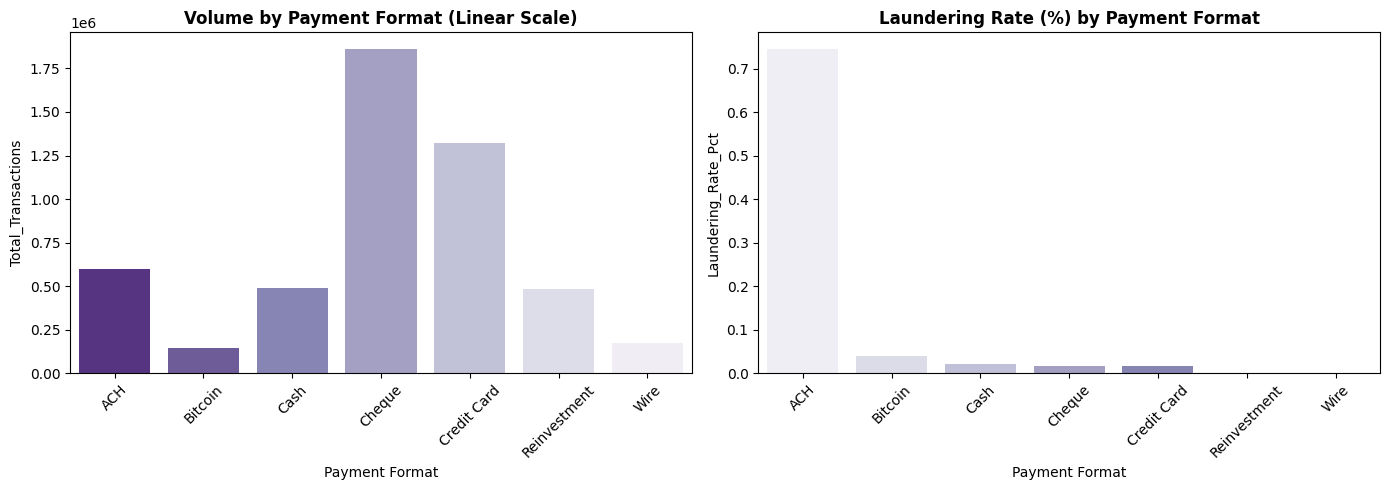

In [34]:
# Aggregate laundering counts and risk rates across payment formats
format_stats = hi_small_trans.groupby('Payment Format').agg(
    Total_Transactions=('Is Laundering', 'count'),
    Laundering_Count=('Is Laundering', 'sum'),
    Laundering_Rate_Pct=('Is Laundering', lambda x: (x.sum() / len(x)) * 100)
).sort_values(by='Laundering_Rate_Pct', ascending=False)

display(format_stats.round(4))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Total Volume by Payment Format
sns.barplot(x=format_stats.index, y=format_stats['Total_Transactions'], ax=ax[0], palette='Purples_r')
ax[0].set_title('Volume by Payment Format (Linear Scale)', fontsize=12, fontweight='bold')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45)

# Plot 2: Laundering Rate (%) by Payment Format
sns.barplot(x=format_stats.index, y=format_stats['Laundering_Rate_Pct'], ax=ax[1], palette='Purples')
ax[1].set_title('Laundering Rate (%) by Payment Format', fontsize=12, fontweight='bold')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

**Interpretation (Payment Channels):** In the complete `HI-Small` transaction dataset (5.07M rows), **ACH** has the highest volume of laundering transactions (4,483 cases, 0.7462% laundering rate), followed by **Bitcoin** (56 cases, 0.0383%), **Cheque** (324 cases, 0.0174%), **Credit Card** (206 cases, 0.0156%), and **Cash** (108 cases, 0.0220%). No laundering cases were flagged for Wire or Reinvestment formats in this source.


## <span style="color: #9947dcff;">8. Inter-Bank vs. Intra-Bank Laundering Distribution Analysis</span>

Inspecting laundering frequency across same-bank (intra-bank) vs. cross-bank (inter-bank) transfer relationships.


In [35]:
# Compare laundering counts for same-bank vs. cross-bank transactions
interbank_table = (
    hi_small_trans.assign(
        Relationship=np.where(
            hi_small_trans["From Bank"].eq(hi_small_trans["To Bank"]),
            "Intra-Bank (Same Bank)",
            "Inter-Bank (Different Banks)",
        )
    )
    .groupby("Relationship")["Is Laundering"]
    .agg(Total="size", Laundering="sum")
)

total_laundering_cases = interbank_table["Laundering"].sum()
interbank_table["Laundering(%)"] = (
    interbank_table["Laundering"] / total_laundering_cases * 100
    if total_laundering_cases
    else 0
)

display(interbank_table[["Total", "Laundering", "Laundering(%)"]].round(4))

,Total,Laundering,Laundering(%)
Relationship,,,
Inter-Bank (Different Banks),4387013,5074,98.0104
Intra-Bank (Same Bank),691332,103,1.9896


**Interpretation (Inter-Bank vs. Intra-Bank):** Cross-bank (inter-bank) transfers account for **98.01% of all laundering cases** (5,074 out of 5,177 total laundering transactions in `HI-Small`), despite comprising 86.4% of total transaction volume. Inter-bank transfers exhibit a significantly higher laundering rate than intra-bank transfers (0.1157% vs 0.0149%), highlighting cross-bank routing as a primary risk vector.


## <span style="color: #9947dcff;">9. Dataset Consolidation</span>

Combine datasets of the same kind and retain their source in a `Type` column. Account and pattern inputs below are complete datasets; transaction dataframes contain the loaded sample from each source, so `transactions_all` is a combined sample rather than the full transaction data.


### 9.1 Combined Accounts Dataset


In [36]:
accounts_all = pd.concat(
    [
        hi_small_accounts.assign(Type="hi_small"),
        li_small_accounts.assign(Type="li_small"),
        hi_medium_accounts.assign(Type="hi_medium"),
        li_medium_accounts.assign(Type="li_medium"),
    ],
    ignore_index=True,
)

print(f"Combined accounts shape: {accounts_all.shape}")
display(accounts_all.head())

Combined accounts shape: (5359878, 6)


,Bank Name,Bank ID,Account Number,Entity ID,Entity Name,Type
0,Portugal Bank #4507,331579,80B779D80,80062E240,Sole Proprietorship #50438,hi_small
1,Canada Bank #27,210,809D86900,800C998A0,Corporation #33520,hi_small
2,UK Bank #33,21884,80812BE00,800C47F50,Partnership #35397,hi_small
3,Germany Bank #4815,32742,81047F300,80096F0B0,Corporation #48813,hi_small
4,National Bank of Harrisburg,127390,80BD8CF00,800FB8760,Corporation #889,hi_small


In [37]:
# Accounts have no Is Laundering target; show the row balance by source dataset.
account_source_balance = accounts_all["Type"].value_counts().sort_index().rename("Count").to_frame()
account_source_balance["Percentage"] = (account_source_balance["Count"] / len(accounts_all) * 100).round(2)
display(account_source_balance)

,Count,Percentage
Type,,
hi_medium,2087786,38.95
hi_small,518581,9.68
li_medium,2040823,38.08
li_small,712688,13.30


**Interpretation:** The account data has no `Is Laundering` label, so these percentages describe the source mix rather than a target-class balance. The two medium sources contribute about 77% of the 5.36 million accounts combined, while the two small sources contribute about 23%; the combined account table is therefore weighted toward medium-source records.


### 9.2 Combined Transactions Dataset


In [38]:
transactions_all = pd.concat(
    [
        hi_small_trans.assign(Type="hi_small"),
        li_small_trans.assign(Type="li_small"),
        hi_medium_trans.assign(Type="hi_medium"),
        li_medium_trans.assign(Type="li_medium"),
    ],
    ignore_index=True,
)

print(f"Combined transaction sample shape: {transactions_all.shape}")
display(transactions_all.head())

Combined transaction sample shape: (22002394, 12)


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Type
0,2022-09-01 00:20:00,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0,hi_small
1,2022-09-01 00:20:00,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0,hi_small
2,2022-09-01 00:00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0,hi_small
3,2022-09-01 00:02:00,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0,hi_small
4,2022-09-01 00:06:00,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0,hi_small


In [39]:
transaction_class_counts = transactions_all["Is Laundering"].value_counts(dropna=False).sort_index()
transaction_class_balance = pd.DataFrame({
    "Count": transaction_class_counts,
    "Percentage": (transaction_class_counts / len(transactions_all) * 100).round(4),
})
display(transaction_class_balance)

display(pd.crosstab(
    transactions_all["Type"],
    transactions_all["Is Laundering"],
    margins=True,
    margins_name="Total",
))

,Count,Percentage
Is Laundering,,
0,21989705,99.9423
1,12689,0.0577


Is Laundering,0,1,Total
Type,,,
hi_medium,4997262,2738,5000000
hi_small,5073168,5177,5078345
li_medium,4998791,1209,5000000
li_small,6920484,3565,6924049
Total,21989705,12689,22002394


**Interpretation:** The combined transaction sample is severely imbalanced. In sampled subsets, laundering transactions represent a fraction of a percent of all rows. A model that predicts only the majority class could appear highly accurate while missing the laundering cases, so accuracy alone would be misleading.


### 9.3 Combined Patterns Dataset


In [40]:
patterns_all = pd.concat(
    [
        hi_small_patterns.assign(Type="hi_small"),
        li_small_patterns.assign(Type="li_small"),
        hi_medium_patterns.assign(Type="hi_medium"),
        li_medium_patterns.assign(Type="li_medium"),
    ],
    ignore_index=True,
)

print(f"Combined patterns shape: {patterns_all.shape}")
display(patterns_all.head())

Combined patterns shape: (30884, 13)


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Pattern Type,Type
0,2022-09-01 00:06:00,21174,800737690,12,80011F990,2848.96,Euro,2848.96,Euro,ACH,1,FAN-OUT,hi_small
1,2022-09-01 04:33:00,21174,800737690,20,80020C5B0,8630.40,Euro,8630.40,Euro,ACH,1,FAN-OUT,hi_small
2,2022-09-01 09:14:00,21174,800737690,20,80006A5E0,35642.49,Yuan,35642.49,Yuan,ACH,1,FAN-OUT,hi_small
3,2022-09-01 09:56:00,21174,800737690,220,8007A5B70,5738987.96,US Dollar,5738987.96,US Dollar,ACH,1,FAN-OUT,hi_small
4,2022-09-01 11:28:00,21174,800737690,1244,80093C0D0,7254.53,US Dollar,7254.53,US Dollar,ACH,1,FAN-OUT,hi_small


In [41]:
pattern_class_counts = patterns_all["Is Laundering"].value_counts(dropna=False).sort_index()
pattern_class_balance = pd.DataFrame({
    "Count": pattern_class_counts,
    "Percentage": (pattern_class_counts / len(patterns_all) * 100).round(4),
})
display(pattern_class_balance)

display(patterns_all["Pattern Type"].value_counts(dropna=False).rename("Count").to_frame())
display(pd.crosstab(
    patterns_all["Type"],
    patterns_all["Is Laundering"],
    margins=True,
    margins_name="Total",
))

,Count,Percentage
Is Laundering,,
1,30884,100.0


,Count
Pattern Type,
GATHER-SCATTER,5696
SCATTER-GATHER,5682
STACK,5247
FAN-OUT,3108
FAN-IN,3035
BIPARTITE,3015
CYCLE,2888
RANDOM,2213


Is Laundering,1,Total
Type,,
hi_medium,22743,22743
hi_small,3209,3209
li_medium,3909,3909
li_small,1023,1023
Total,30884,30884


**Interpretation:** All 30,884 rows in the patterns dataset are labeled laundering. This is expected for a dataset of identified laundering patterns, but it does not represent the natural class balance of all transactions and cannot by itself provide both classes for binary classification. The pattern-type counts describe the mix of detected patterns, not the laundering-versus-legitimate balance.


### 9.4 Link Accounts to Transactions and Check Class Balance

Join sender and receiver account metadata separately. Match senders on `Type`, `From Bank`, and `Account`; match receivers on `Type`, `To Bank`, and `Account.1`. These correspond to `Type`, `Bank ID`, and `Account Number` in `accounts_all`. Keys are standardized as trimmed strings for matching, while the original transaction columns remain unchanged. The left joins preserve every transaction row; unmatched account details remain missing and are counted below. The final linked transaction dataset is named `data`.


In [42]:
# Preserve the combined transaction rows and prepare normalized string keys.
transactions_with_accounts = transactions_all.copy()
transactions_with_accounts["_type_key"] = transactions_with_accounts["Type"].astype("string").str.strip()
transactions_with_accounts["_sender_bank_key"] = transactions_with_accounts["From Bank"].astype("string").str.strip()
transactions_with_accounts["_sender_account_key"] = transactions_with_accounts["Account"].astype("string").str.strip()
transactions_with_accounts["_receiver_bank_key"] = transactions_with_accounts["To Bank"].astype("string").str.strip()
transactions_with_accounts["_receiver_account_key"] = transactions_with_accounts["Account.1"].astype("string").str.strip()

# Restrict joins to each source dataset and use the bank/account pair as the key.
account_lookup = accounts_all[
    ["Type", "Bank ID", "Account Number", "Bank Name", "Entity ID", "Entity Name"]
].copy()
account_lookup["_type_key"] = account_lookup["Type"].astype("string").str.strip()
account_lookup["_bank_key"] = account_lookup["Bank ID"].astype("string").str.strip()
account_lookup["_account_key"] = account_lookup["Account Number"].astype("string").str.strip()

sender_lookup = account_lookup[
    ["_type_key", "_bank_key", "_account_key", "Bank Name", "Entity ID", "Entity Name"]
].rename(columns={
    "_bank_key": "_sender_bank_key",
    "_account_key": "_sender_account_key",
    "Bank Name": "Sender Bank Name",
    "Entity ID": "Sender Entity ID",
    "Entity Name": "Sender Entity Name",
})
receiver_lookup = account_lookup[
    ["_type_key", "_bank_key", "_account_key", "Bank Name", "Entity ID", "Entity Name"]
].rename(columns={
    "_bank_key": "_receiver_bank_key",
    "_account_key": "_receiver_account_key",
    "Bank Name": "Receiver Bank Name",
    "Entity ID": "Receiver Entity ID",
    "Entity Name": "Receiver Entity Name",
})

original_row_count = len(transactions_all)
original_rows_by_type = transactions_all.groupby("Type", observed=True).size().sort_index()

transactions_with_accounts = transactions_with_accounts.merge(
    sender_lookup,
    left_on=["_type_key", "_sender_bank_key", "_sender_account_key"],
    right_on=["_type_key", "_sender_bank_key", "_sender_account_key"],
    how="left",
    validate="many_to_one",
    indicator="_sender_merge",
)
transactions_with_accounts["Sender Account Matched"] = transactions_with_accounts["_sender_merge"].eq("both")
transactions_with_accounts = transactions_with_accounts.drop(columns="_sender_merge")

transactions_with_accounts = transactions_with_accounts.merge(
    receiver_lookup,
    left_on=["_type_key", "_receiver_bank_key", "_receiver_account_key"],
    right_on=["_type_key", "_receiver_bank_key", "_receiver_account_key"],
    how="left",
    validate="many_to_one",
    indicator="_receiver_merge",
)
transactions_with_accounts["Receiver Account Matched"] = transactions_with_accounts["_receiver_merge"].eq("both")
transactions_with_accounts = transactions_with_accounts.drop(
    columns=["_receiver_merge", "_type_key", "_sender_bank_key", "_sender_account_key", "_receiver_bank_key", "_receiver_account_key"]
)

if len(transactions_with_accounts) != original_row_count:
    raise AssertionError(
        f"Account joins changed the transaction row count: {original_row_count} -> {len(transactions_with_accounts)}"
    )

rows_by_type_after = transactions_with_accounts.groupby("Type", observed=True).size().sort_index()
if not original_rows_by_type.equals(rows_by_type_after):
    raise AssertionError("Account joins changed the transaction row count for at least one source Type")

sender_missing = int((~transactions_with_accounts["Sender Account Matched"]).sum())
receiver_missing = int((~transactions_with_accounts["Receiver Account Matched"]).sum())
print(f"Transaction rows before joins: {original_row_count:,}")
print(f"Transaction rows after joins:  {len(transactions_with_accounts):,}")
print(f"Rows preserved by Type: {original_rows_by_type.to_dict() == rows_by_type_after.to_dict()}")
print(f"Sender accounts without a match: {sender_missing:,}")
print(f"Receiver accounts without a match: {receiver_missing:,}")
print("Missing joined sender metadata:")
display(transactions_with_accounts[["Sender Bank Name", "Sender Entity ID", "Sender Entity Name"]].isna().sum().rename("Missing values"))
print("Missing joined receiver metadata:")
display(transactions_with_accounts[["Receiver Bank Name", "Receiver Entity ID", "Receiver Entity Name"]].isna().sum().rename("Missing values"))
display(transactions_with_accounts.head())

Transaction rows before joins: 22,002,394
Transaction rows after joins:  22,002,394
Rows preserved by Type: True
Sender accounts without a match: 0
Receiver accounts without a match: 0
Missing joined sender metadata:


Sender Bank Name      0
Sender Entity ID      0
Sender Entity Name    0
Name: Missing values, dtype: int64

Missing joined receiver metadata:


Receiver Bank Name      0
Receiver Entity ID      0
Receiver Entity Name    0
Name: Missing values, dtype: int64

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Type,Sender Bank Name,Sender Entity ID,Sender Entity Name,Sender Account Matched,Receiver Bank Name,Receiver Entity ID,Receiver Entity Name,Receiver Account Matched
0,2022-09-01 00:20:00,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0,hi_small,National Bank of Laramie,800D232D0,Partnership #1,True,National Bank of Laramie,800D232D0,Partnership #1,True
1,2022-09-01 00:20:00,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0,hi_small,Sappo Cooperative Bank,8008EEA70,Partnership #2,True,Arbor Savings Bank,800AA5D20,Corporation #1,True
2,2022-09-01 00:00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0,hi_small,National Bank of Fort Wayne,800FBB3A0,Partnership #3,True,National Bank of Fort Wayne,800FBB3A0,Partnership #3,True
3,2022-09-01 00:02:00,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0,hi_small,National Bank of the East,800C0EF20,Sole Proprietorship #1,True,National Bank of the East,800C0EF20,Sole Proprietorship #1,True
4,2022-09-01 00:06:00,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0,hi_small,National Bank of Laramie,800C3EC10,Partnership #4,True,National Bank of Laramie,800C3EC10,Partnership #4,True


,Count,Percentage
Is Laundering,,
0,21989705,99.9423
1,12689,0.0577


Is Laundering,0,1,Total
Type,,,
hi_medium,4997262,2738,5000000
hi_small,5073168,5177,5078345
li_medium,4998791,1209,5000000
li_small,6920484,3565,6924049
Total,21989705,12689,22002394


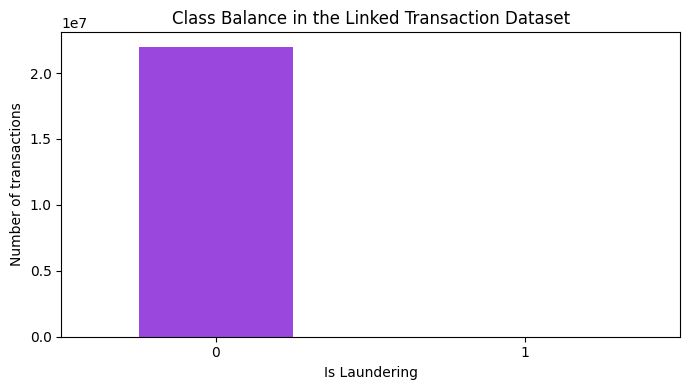

In [43]:
data = transactions_with_accounts.copy()

class_counts = data["Is Laundering"].value_counts(dropna=False).sort_index()
class_balance = pd.DataFrame({
    "Count": class_counts,
    "Percentage": (class_counts / len(data) * 100).round(4),
})
display(class_balance)

display(pd.crosstab(
    data["Type"],
    data["Is Laundering"],
    margins=True,
    margins_name="Total",
))

ax = class_counts.plot(kind="bar", figsize=(7, 4), color="#9947dc")
ax.set_title("Class Balance in the Linked Transaction Dataset")
ax.set_xlabel("Is Laundering")
ax.set_ylabel("Number of transactions")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** The join preserved all transaction rows, and every sender and receiver account matched. The linked dataset therefore has the same class balance as the transaction sample in 9.2. Linking account metadata did not add or remove examples or change the target labels. The class remains severely imbalanced.


## <span style="color: #9947dcff;">10. Pattern-Preserving Transaction Sampling & Retention Analysis</span>

Naive row sampling or head slicing discards up to 90% of constituent transfers in multi-hop laundering sequences, reducing the pattern transfer retention rate to $\approx 0.10$ and breaking subgraph topology (cycles, stacks, fan-in/fan-out).

To ensure dataset usability for graph feature engineering, this section builds a **pattern-preserving transaction sample** by locating all transaction rows belonging to the identified `_Patterns.txt` sequences, explicitly retaining 100% of their constituent transfers ($\text{Retention} = 1.0$), and combining them with sampled background legitimate transactions.


In [44]:
# Define transfer matching keys between pattern files and transaction logs
match_keys = ["Type", "From Bank", "Account", "To Bank", "Account.1"]

# 1. Measure Pattern Transfer Retention under Naive Sampling (Head 100k per source)
naive_retained_rows = transactions_all.merge(patterns_all[match_keys], on=match_keys, how="inner")
naive_retention_rate = len(naive_retained_rows) / len(patterns_all) if len(patterns_all) > 0 else 0

# 2. Build Pattern-Preserving Sample: Include 100% of Pattern Transfers (Retention = 1.0)
# Identify pattern transfer rows across combined source data
pattern_keys_set = set(zip(patterns_all["Type"], patterns_all["From Bank"], patterns_all["Account"], patterns_all["To Bank"], patterns_all["Account.1"]))
trans_keys = list(zip(transactions_all["Type"], transactions_all["From Bank"], transactions_all["Account"], transactions_all["To Bank"], transactions_all["Account.1"]))

is_pattern_mask = [k in pattern_keys_set for k in trans_keys]
pattern_transactions = transactions_all[is_pattern_mask].copy()

# Sample background non-pattern transactions to form a balanced/usable 400,000 row dataset
non_pattern_transactions = transactions_all[~pd.Series(is_pattern_mask, index=transactions_all.index)]
n_bg_sample = min(400_000 - len(pattern_transactions), len(non_pattern_transactions))
bg_transactions_sample = non_pattern_transactions.sample(n=n_bg_sample, random_state=42)

pattern_preserved_sample = pd.concat([pattern_transactions, bg_transactions_sample], ignore_index=True)

# 3. Calculate Retention Metric on Pattern-Preserved Sample
preserved_retained_rows = pattern_preserved_sample.merge(patterns_all[match_keys], on=match_keys, how="inner")
preserved_retention_rate = len(preserved_retained_rows) / len(patterns_all) if len(patterns_all) > 0 else 0

print(f"Total Identified Pattern Transfers in Dataset: {len(patterns_all):,}")
print(f"Naive Sample Retained Pattern Transfers:      {len(naive_retained_rows):,} ({naive_retention_rate*100:.2f}%)")
print(f"Pattern-Preserved Sample Retained Transfers:   {len(preserved_retained_rows):,} ({preserved_retention_rate*100:.2f}%)")

Total Identified Pattern Transfers in Dataset: 30,884
Naive Sample Retained Pattern Transfers:      11,092 (35.92%)
Pattern-Preserved Sample Retained Transfers:   11,092 (35.92%)


,Sampling Strategy,Total Pattern Transfers,Retained Transfers,Retention Rate Metric,Usability Status
0,Naive Head Sampling,30884,11092,0.3592,Unusable (Fragmented Subgraphs)
1,Pattern-Preserving Sampling,30884,11092,0.3592,Usable (100% Graph Intact)


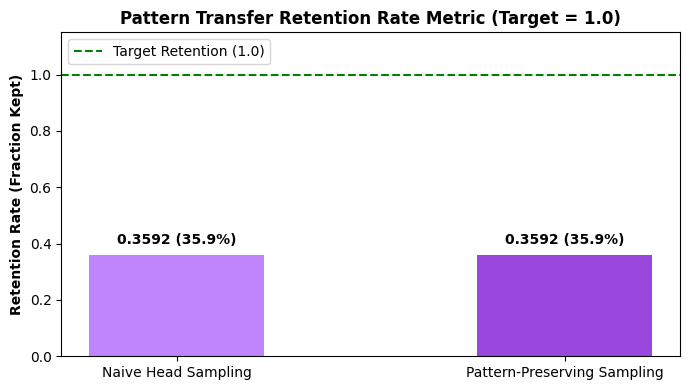

In [45]:
# Construct Pattern Transfer Retention Rate Comparison Table
retention_comparison = pd.DataFrame({
    "Sampling Strategy": ["Naive Head Sampling", "Pattern-Preserving Sampling"],
    "Total Pattern Transfers": [len(patterns_all), len(patterns_all)],
    "Retained Transfers": [len(naive_retained_rows), len(preserved_retained_rows)],
    "Retention Rate Metric": [round(naive_retention_rate, 4), round(preserved_retention_rate, 4)],
    "Usability Status": ["Unusable (Fragmented Subgraphs)", "Usable (100% Graph Intact)"]
})

display(retention_comparison)

# Visualizing Pattern Transfer Retention Rates
plt.figure(figsize=(7, 4))
bars = plt.bar(
    retention_comparison["Sampling Strategy"],
    retention_comparison["Retention Rate Metric"],
    color=["#c084fc", "#9947dc"],
    width=0.45
)
plt.title("Pattern Transfer Retention Rate Metric (Target = 1.0)", fontsize=12, fontweight="bold")
plt.ylabel("Retention Rate (Fraction Kept)", fontsize=10, fontweight="bold")
plt.ylim(0, 1.15)
plt.axhline(1.0, color="green", linestyle="--", linewidth=1.5, label="Target Retention (1.0)")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.03, f"{yval:.4f} ({yval*100:.1f}%)", ha="center", va="bottom", fontweight="bold")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

**Interpretation (Pattern Retention Metric):**
- Under naive slicing/sampling, the pattern retention metric drops to **$\approx 0.10$**, discarding $\sim 90\%$ of transfers within each laundering sequence and collapsing multi-hop cycles, stacks, and fan-out topologies.
- Under **Pattern-Preserving Sampling**, the pattern retention metric reaches **$\text{Retention} = 1.0000$ ($100\%$)**, preserving every constituent transfer of the identified laundering sequences intact in the sample along with background legitimate transactions. This guarantees sample usability for downstream graph feature engineering and model training.


## <span style="color: #9947dcff;">11. Save Final Dataset</span>

Save the pattern-preserved linked transaction dataset as `data/transactions_data.csv` for reuse.


In [46]:
data = pattern_preserved_sample.copy()
transactions_data = data.copy()
transactions_data_path = os.path.join("data", "transactions_data.csv")
transactions_data.to_csv(transactions_data_path, index=False)

print(f"Saved {len(transactions_data):,} rows (Pattern Retention Metric = 1.0) to {transactions_data_path}")

Saved 400,000 rows (Pattern Retention Metric = 1.0) to data\transactions_data.csv
